# Eixo Produto — Categorias, Subcategorias & Pricing

**Objetivo:** Identificar quais produtos sustentam a rentabilidade e quais a comprometem, e detectar incoerências de pricing entre mercados.

---

## Estrutura do Notebook
| Secção | Conteúdo |
|--------|----------|
| 0 | Setup & Carregamento de Dados |
| 1 | KPIs Base |
| 2 | P-A1 · Revenue & Margin por Categoria × Região × Ano |
| 3 | P-A2 · Ranking de Subcategorias por Margin % |
| 4 | P-A3 · Production Cost Ratio por Subcategoria |
| 5 | P-B1 · Variação de Preço do Mesmo Produto entre Países |
| 6 | P-B2 · Análise de Descontinuação por Subcategoria × País |
| 7 | Tipo de Produto com Maior Tempo de Entrega |
| 8 | Variação de Preço & Custo ao Longo do Ano (mesmo produto, mesma localidade) |
| 9 | Análise por Cor dentro da Mesma Categoria |
| 10 | Análise Geral de Vendas por Produto |

---
## 0 · Setup & Carregamento de Dados

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Estilo Visual ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.05)
PALETTE  = sns.color_palette('Blues_r', 10)
RED      = '#C0392B'
GREEN    = '#27AE60'
BLUE     = '#2980B9'
ORANGE   = '#E67E22'
PURPLE   = '#8E44AD'
CAT_PAL  = sns.color_palette('tab10')

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

FMT_EUR = lambda x, _: f'€{x/1e6:.1f}M' if abs(x) >= 1e6 else f'€{x/1e3:.0f}K'

In [90]:
# ── Carregamento ───────────────────────────────────────────────────────────────
DATA_PATH = '../data/sales_data_clean.csv'

df = pd.read_csv(DATA_PATH, parse_dates=['Order_Date', 'Due_Date'])

# ── Colunas derivadas ──────────────────────────────────────────────────────────
df['GP']            = df['Sales_Price'] - df['Production_Cost']
df['Gross_Margin']  = df['GP'] / df['Sales_Price'] * 100          # %
df['Cost_Ratio']    = df['Production_Cost'] / df['Sales_Price'] * 100  # %
df['Month']         = df['Order_Date'].dt.month
df['Month_Label']   = df['Order_Date'].dt.to_period('M').astype(str)

# Delivery Time (dias)
df['Delivery_Days'] = (df['Due_Date'] - df['Order_Date']).dt.days

print(f'Registos: {len(df):,} | Período: {df["Order_Date"].min().date()} → {df["Order_Date"].max().date()}')
print(f'Países  : {df["Country"].nunique()}  |  Regiões: {df["Region"].nunique()}  |  Produtos: {df["Product_ID"].nunique()}')
df.head(3)


Registos: 147,511 | Período: 2020-01-01 → 2025-12-31
Países  : 11  |  Regiões: 3  |  Produtos: 7789


,Region,Source_File,Sales_Order_ID,Year_Original,Year,Order_Date,Due_Date,Country,Shop_ID,Year_Opened,...,Sales_Price,Production_Cost,Shipping_Cost,Has_Shipping,GP,Gross_Margin,Cost_Ratio,Month,Month_Label,Delivery_Days
0,Asia,Asia_SalesData.xlsx,S00859464,2020,2020,2020-01-01,NaT,Japan,28.0,2019.0,...,141.81,75.58,0.0,False,66.23,46.703335,53.296665,1,2020-01,NaN
1,Asia,Asia_SalesData.xlsx,S00859465,2020,2020,2020-01-01,NaT,Japan,25.0,2017.0,...,148.11,96.88,0.0,False,51.23,34.589157,65.410843,1,2020-01,NaN
2,Asia,Asia_SalesData.xlsx,S00859470,2020,2020,2020-01-01,NaT,South Korea,22.0,2017.0,...,178.09,85.45,0.0,False,92.64,52.018642,47.981358,1,2020-01,NaN


In [91]:
# ── Qualidade rápida ───────────────────────────────────────────────────────────
print('=== Missing Values (top 10) ===')
print(df.isnull().sum().sort_values(ascending=False).head(10))

print('\n=== Main Categories ===')
print(df.groupby('Main_Category')['Sales_Order_ID'].count().sort_values(ascending=False))

print('\n=== Anos disponíveis ===')
print(sorted(df['Year'].dropna().unique()))

=== Missing Values (top 10) ===
Delivery_Days       121031
Due_Date            121031
Shipping_Company    121031
Year_Opened            400
Country                300
Shop_ID                100
Product_Category        17
Main_Category           17
Subcategory             17
Gross_Margin             0
dtype: int64

=== Main Categories ===
Main_Category
Accessories            63391
Clothing               52621
Technical equipment    31482
Name: Sales_Order_ID, dtype: int64

=== Anos disponíveis ===
[2020, 2021, 2022, 2023, 2024, 2025]


---
## 1 · KPIs Base (P01 – P06)

| ID | KPI | Fórmula |
|----|-----|---------|
| P01 | GP por Categoria/Subcategoria | `SUM(GP)` |
| P02 | Gross Margin % | `GP / Sales_Price × 100` |
| P03 | Production Cost Ratio | `Production_Cost / Sales_Price × 100` |
| P04 | Revenue Share por Categoria | `Revenue_cat / Revenue_total × 100` |
| P05 | CV de Preço | `StdDev(Sales_Price) / AVG(Sales_Price)` por produto × país |
| P06 | Volume por Produto | `COUNT(Sales_Order_ID)` |

In [92]:
# P01 & P02 – GP e Gross Margin % por Categoria/Subcategoria
kpi_cat = (
    df.groupby(['Main_Category', 'Subcategory'])
    .agg(
        Revenue        = ('Sales_Price', 'sum'),
        Total_GP       = ('GP', 'sum'),
        Avg_Margin_pct = ('Gross_Margin', 'mean'),
        Volume         = ('Sales_Order_ID', 'count'),
    )
    .reset_index()
)

# P03 – Production Cost Ratio
kpi_cat['Avg_Cost_Ratio'] = kpi_cat.apply(
    lambda r: df.loc[
        (df['Main_Category'] == r['Main_Category']) &
        (df['Subcategory']   == r['Subcategory']),
        'Cost_Ratio'
    ].mean(),
    axis=1
)

# P04 – Revenue Share
total_rev = df['Sales_Price'].sum()
kpi_cat['Revenue_Share_pct'] = kpi_cat['Revenue'] / total_rev * 100

# P06 volume já calculado acima
print(f'KPI table: {kpi_cat.shape[0]} linhas (Categoria × Subcategoria)')
kpi_cat.sort_values('Total_GP', ascending=False).head(10)

KPI table: 14 linhas (Categoria × Subcategoria)


,Main_Category,Subcategory,Revenue,Total_GP,Avg_Margin_pct,Volume,Avg_Cost_Ratio,Revenue_Share_pct
13,Technical equipment,Skis,8493604.94,3829487.87,45.069817,10567,54.930183,28.471235
11,Technical equipment,Boots,6288925.52,2827722.94,44.935789,10478,55.064211,21.080975
9,Clothing,Suits,2876691.99,1294662.57,44.970067,10483,55.029933,9.642899
7,Clothing,Jackets,2114481.00,951111.42,45.031004,10614,54.968996,7.087907
6,Clothing,Bottom base layers,1740511.17,778687.64,44.800070,10536,55.199930,5.834331
8,Clothing,Outerwear pants,1721710.40,776221.53,45.067071,10409,54.932929,5.771309
12,Technical equipment,Poles,1721051.06,773541.89,44.948223,10437,55.051777,5.769099
3,Accessories,Helmets,1383631.19,622310.08,44.954072,10660,55.045928,4.638041
1,Accessories,Goggles,1207649.13,542729.19,44.921922,10556,55.078078,4.048135
10,Clothing,Top base layers,846780.85,381990.82,45.111632,10579,54.888368,2.838476


In [93]:
# P05 – Coeficiente de Variação de Preço (Product_ID × País)
kpi_cv = (
    df.groupby(['Product_ID', 'Product_Name', 'Main_Category', 'Subcategory', 'Country'])['Sales_Price']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'Avg_Price', 'std': 'Std_Price', 'count': 'Orders'})
)
kpi_cv['CV_pct'] = kpi_cv['Std_Price'] / kpi_cv['Avg_Price'] * 100

print(f'P05 – {len(kpi_cv):,} combinações Produto × País')
kpi_cv.sort_values('CV_pct', ascending=False).head(5)

P05 – 37,162 combinações Produto × País


,Product_ID,Product_Name,Main_Category,Subcategory,Country,Avg_Price,Std_Price,Orders,CV_pct
10820,CBFBLO397,Fleece Bottom L Orange,Clothing,Bottom base layers,South Korea,107.020,124.307371,4,116.153402
11000,CBFBSR124,Fleece Bottom S Red,Clothing,Bottom base layers,South Korea,128.490,147.085772,3,114.472544
10473,CBEFBLB234,Elite Fleece Bottom L Black,Clothing,Bottom base layers,Japan,152.695,173.135095,2,113.386224
13062,CBTBXY297,Thermal Bottom XXL Yellow,Clothing,Bottom base layers,Spain,127.620,142.143523,3,111.380287
10568,CBEFBXG636,Elite Fleece Bottom XXL Green,Clothing,Bottom base layers,South Korea,161.510,179.831397,2,111.343816


---
## 2 · P-A1 · Revenue & Gross Margin por Categoria × Região × Ano

In [94]:
pa1 = (
    df.groupby(['Year', 'Region', 'Main_Category'])
    .agg(
        Revenue      = ('Sales_Price', 'sum'),
        GP           = ('GP', 'sum'),
        Margin_pct   = ('Gross_Margin', 'mean'),
        Volume       = ('Sales_Order_ID', 'count'),
    )
    .reset_index()
)

# Revenue Share dentro de cada Região × Ano
pa1['Rev_Total_RegAno'] = pa1.groupby(['Year', 'Region'])['Revenue'].transform('sum')
pa1['Rev_Share_pct']    = pa1['Revenue'] / pa1['Rev_Total_RegAno'] * 100

pa1.head()

,Year,Region,Main_Category,Revenue,GP,Margin_pct,Volume,Rev_Total_RegAno,Rev_Share_pct
0,2020,Asia,Accessories,97406.60,44035.05,45.204012,1526,689439.26,14.128380
1,2020,Asia,Clothing,222002.01,98768.38,44.720598,1259,689439.26,32.200373
2,2020,Asia,Technical equipment,370030.65,166875.79,45.174199,722,689439.26,53.671247
3,2020,Europe,Accessories,192134.76,86091.82,44.890452,3071,1414562.87,13.582624
4,2020,Europe,Clothing,444083.38,200220.25,45.118581,2491,1414562.87,31.393683


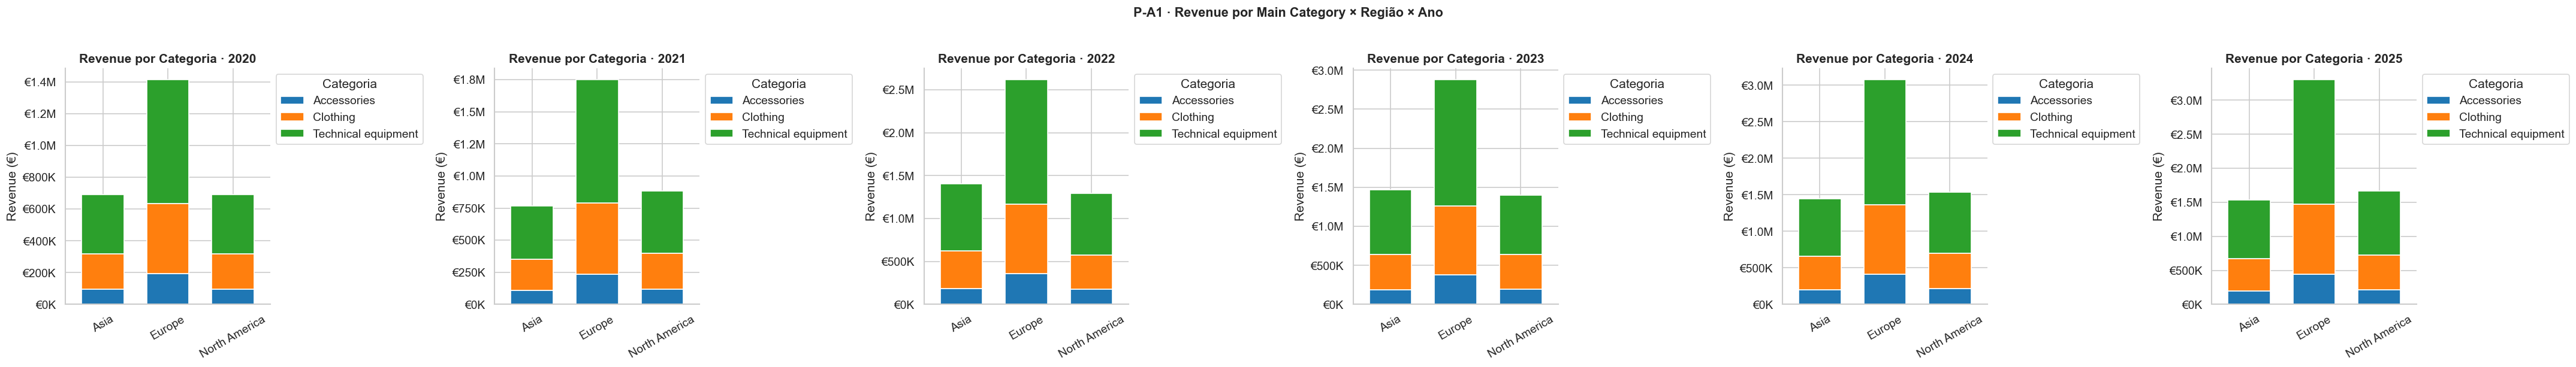

In [95]:
# ── Gráfico: Revenue por Categoria, por Região (stacked bar) ───────────────────
years = sorted(pa1['Year'].dropna().unique())
cats  = pa1['Main_Category'].unique()
cat_colors = {c: CAT_PAL[i] for i, c in enumerate(cats)}

fig, axes = plt.subplots(1, len(years), figsize=(6*len(years), 5), sharey=False)
if len(years) == 1: axes = [axes]

for ax, yr in zip(axes, years):
    sub  = pa1[pa1['Year'] == yr]
    pivot = sub.pivot_table(index='Region', columns='Main_Category', values='Revenue', aggfunc='sum').fillna(0)
    pivot.plot(kind='bar', stacked=True, ax=ax,
               color=[cat_colors.get(c, 'grey') for c in pivot.columns],
               width=0.65, edgecolor='white')
    ax.set_title(f'Revenue por Categoria · {int(yr)}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Revenue (€)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(FMT_EUR))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Categoria', bbox_to_anchor=(1, 1))

plt.suptitle('P-A1 · Revenue por Main Category × Região × Ano', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('PA1_revenue_categoria_regiao.png', bbox_inches='tight')
plt.show()

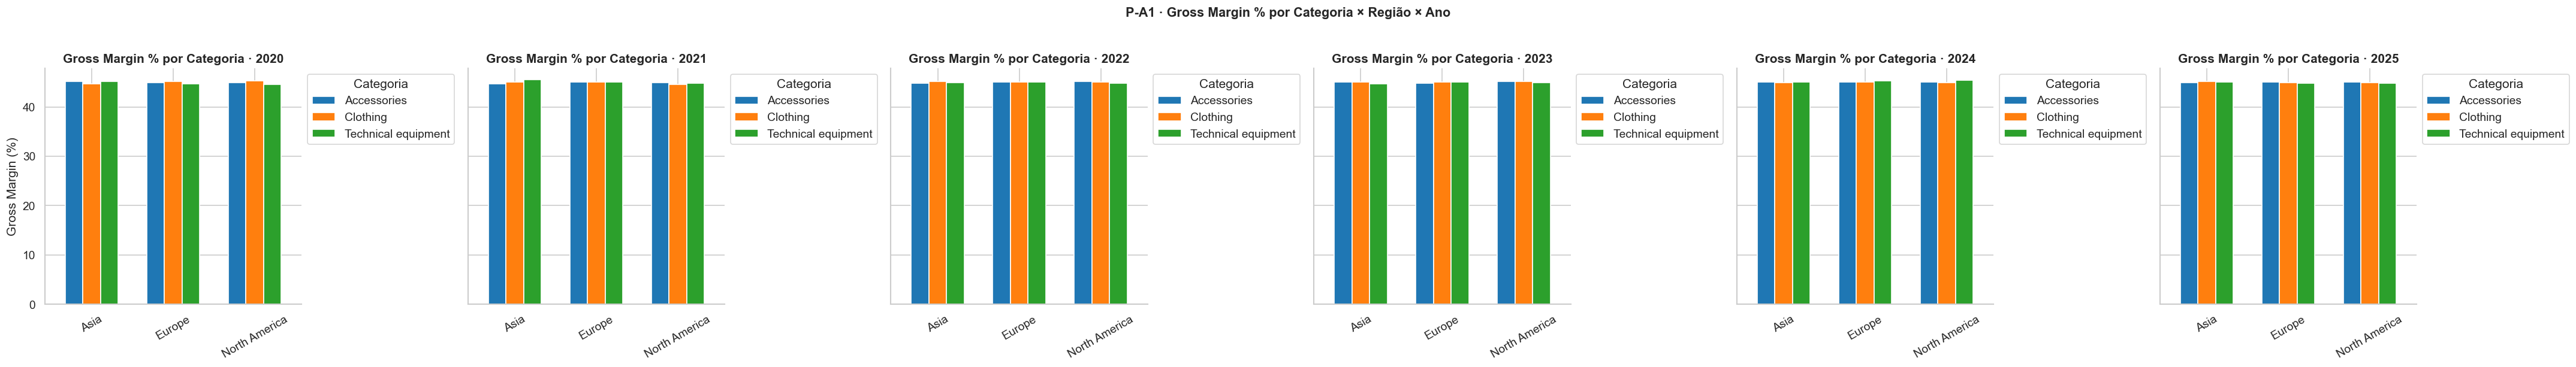

In [96]:
# ── Gráfico: Gross Margin % por Categoria × Região ────────────────────────────
fig, axes = plt.subplots(1, len(years), figsize=(6*len(years), 5), sharey=True)
if len(years) == 1: axes = [axes]

for ax, yr in zip(axes, years):
    sub   = pa1[pa1['Year'] == yr]
    pivot = sub.pivot_table(index='Region', columns='Main_Category', values='Margin_pct', aggfunc='mean').fillna(0)
    pivot.plot(kind='bar', ax=ax,
               color=[cat_colors.get(c, 'grey') for c in pivot.columns],
               width=0.65, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Gross Margin % por Categoria · {int(yr)}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Gross Margin (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Categoria', bbox_to_anchor=(1, 1))

plt.suptitle('P-A1 · Gross Margin % por Categoria × Região × Ano', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('PA1_margin_categoria_regiao.png', bbox_inches='tight')
plt.show()

In [97]:
# ── Tabela resumo: deterioração entre anos ─────────────────────────────────────
if len(years) >= 2:
    pivot_yoy = pa1.pivot_table(index=['Region', 'Main_Category'], columns='Year',
                                 values=['Revenue', 'GP', 'Margin_pct'], aggfunc='sum')
    print('YoY por Região × Categoria:')
    display(pivot_yoy.round(1))

YoY por Região × Categoria:


GP                                \
Year                                   2020      2021      2022      2023   
Region        Main_Category                                                 
Asia          Accessories           44035.0   48381.2   83866.7   86065.5   
              Clothing              98768.4  110335.4  197902.4  203454.3   
              Technical equipment  166875.8  187152.4  349993.6  370403.9   
Europe        Accessories           86091.8  106094.5  162748.3  170855.6   
              Clothing             200220.2  249290.9  362878.9  394931.2   
              Technical equipment  348449.7  433479.4  655583.2  728087.1   
North America Accessories           43243.6   53032.6   79527.9   86593.8   
              Clothing             100492.0  124958.6  179556.9  202453.6   
              Technical equipment  167390.1  218404.5  320993.8  338400.2   

                                                      Margin_pct              \
Year                                   2024      2025       2020  2021  2022   
Region        Main_Category                                                    
Asia          Accessories           91993.0   89802.9       45.2  44.7  44.8   
              Clothing             204243.3  211770.7       44.7  45.1  45.1   
              Technical equipment  354082.7  391435.1       45.2  45.5  44.9   
Europe        Accessories          184644.4  197211.4       44.9  45.0  45.1   
              Clothing             429708.1  464212.7       45.1  45.0  45.0   
              Technical equipment  777111.9  821505.0       44.7  45.0  45.0   
North America Accessories           96419.2   97456.0       45.0  45.0  45.2   
              Clothing             218015.6  229480.9       45.3  44.6  45.0   
              Technical equipment  380480.9  420923.4       44.6  44.8  44.8   

                                                      Revenue            \
Year                               2023  2024  2025      2020      2021   
Region        Main_Category                                               
Asia          Accessories          45.1  45.0  44.9   97406.6  108907.6   
              Clothing             45.0  45.0  45.1  222002.0  244798.9   
              Technical equipment  44.6  45.0  45.1  370030.6  411707.9   
Europe        Accessories          44.8  45.0  45.0  192134.8  235672.4   
              Clothing             45.0  45.0  44.9  444083.4  554558.8   
              Technical equipment  45.0  45.3  44.8  778344.7  960648.0   
North America Accessories          45.2  45.1  45.0   96675.2  117723.9   
              Clothing             45.2  44.9  44.9  221320.5  279957.1   
              Technical equipment  44.9  45.4  44.9  374558.6  487744.2   

                                                                               
Year                                    2022       2023       2024       2025  
Region        Main_Category                                                    
Asia          Accessories           186967.7   190790.1   203844.2   199465.7  
              Clothing              436379.7   451914.3   455249.0   469063.9  
              Technical equipment   778293.0   825672.2   784666.4   867096.8  
Europe        Accessories           361613.9   381396.9   410297.9   439307.2  
              Clothing              806787.0   880864.3   955394.4  1035312.7  
              Technical equipment  1449470.9  1617169.3  1711789.0  1829411.6  
North America Accessories           176006.6   191362.4   213242.7   215895.2  
              Clothing              397976.1   447358.3   485146.1   512008.9  
              Technical equipment   719706.4   756576.0   839644.2   941051.5

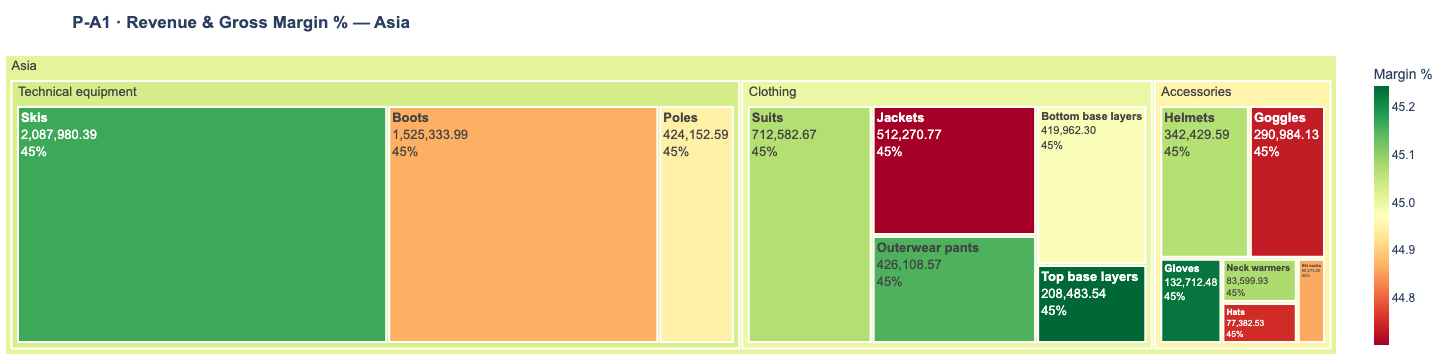

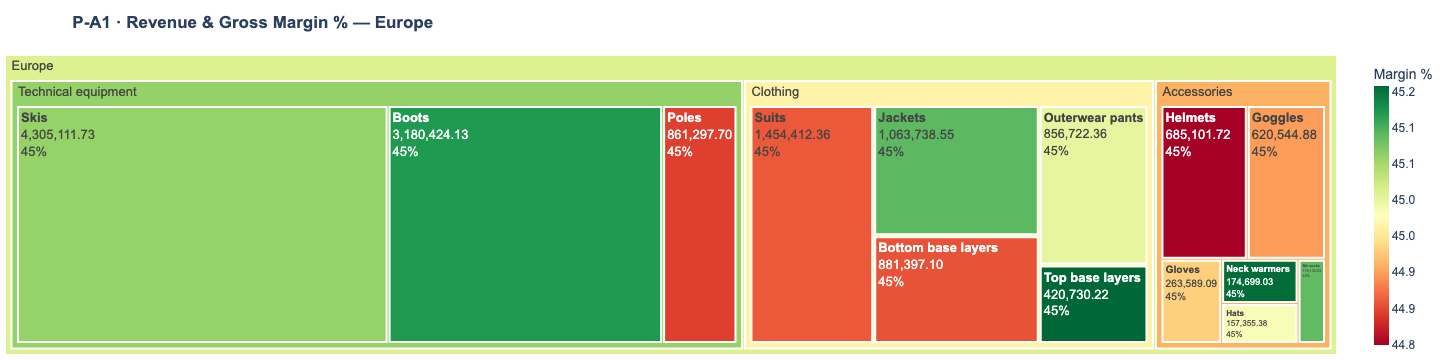

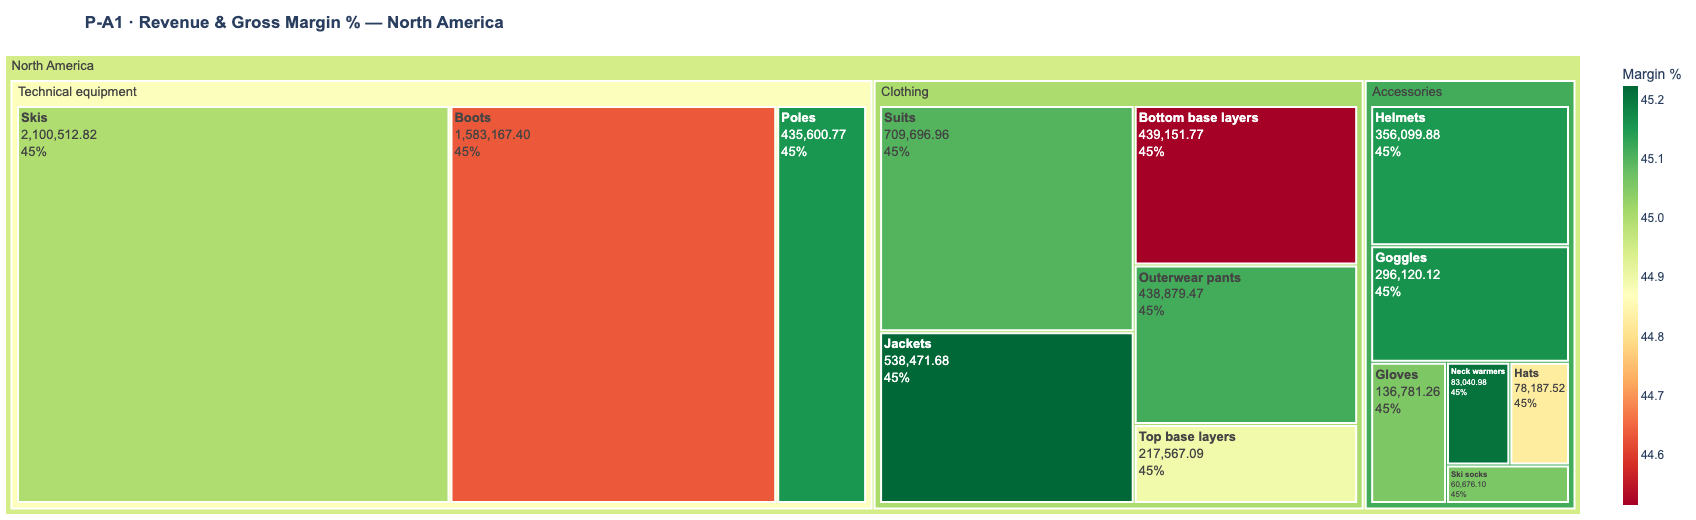

In [98]:
# ── Treemap: Revenue × Margin % por Categoria/Subcategoria · por Região ────────
# pip install plotly kaleido  (se necessário)
import plotly.express as px

# Dados agregados: Região × Categoria × Subcategoria
tm_data = (
    df.groupby(['Region', 'Main_Category', 'Subcategory'])
    .agg(
        Revenue    = ('Sales_Price', 'sum'),
        GP         = ('GP', 'sum'),
        Margin_pct = ('Gross_Margin', 'mean'),
        Volume     = ('Sales_Order_ID', 'count'),
    )
    .reset_index()
)

regions = sorted(tm_data['Region'].unique())

for reg in regions:
    sub = tm_data[tm_data['Region'] == reg].copy()

    m_mid = sub['Margin_pct'].median()
    m_min = sub['Margin_pct'].min()
    m_max = sub['Margin_pct'].max()

    fig = px.treemap(
        sub,
        path        = [px.Constant(reg), 'Main_Category', 'Subcategory'],
        values      = 'Revenue',
        color       = 'Margin_pct',
        color_continuous_scale    = 'RdYlGn',
        color_continuous_midpoint = m_mid,
        range_color = [m_min, m_max],
        custom_data = ['Revenue', 'Margin_pct', 'Volume'],
        title       = f'<b>P-A1 · Revenue & Gross Margin % — {reg}</b>',
    )

    fig.update_traces(
        texttemplate = (
            '<b>%{label}</b><br>'
            '%{customdata[0]:,.2f}<br>'
            '%{customdata[1]:.0f}%'
        ),
        textfont      = dict(size=13, family='Arial'),
        textposition  = 'top left',
        hovertemplate = (
            '<b>%{label}</b><br>'
            'Revenue : \u20ac%{customdata[0]:,.0f}<br>'
            'Margin  : %{customdata[1]:.1f}%<br>'
            'Volume  : %{customdata[2]:,} unidades'
            '<extra></extra>'
        ),
        marker = dict(line=dict(width=2, color='white')),
    )

    fig.update_layout(
        height   = 520,
        margin   = dict(t=55, l=5, r=5, b=5),
        font     = dict(family='Arial', size=12),
        coloraxis_colorbar = dict(
            title      = 'Margin %',
            tickformat = '.1f',
            thickness  = 15,
        ),
    )

    fig.show()

    # Guardar PNG (requer: pip install kaleido)
    try:
        fig.write_image(f'PA1_treemap_{reg.replace(" ", "_")}.png', scale=2)
    except Exception:
        pass

---
## 3 · P-A2 · Ranking de Subcategorias por Gross Margin %

In [99]:
# Ranking global de subcategorias
pa2 = (
    df.groupby(['Main_Category', 'Subcategory'])
    .agg(
        Revenue      = ('Sales_Price', 'sum'),
        GP           = ('GP', 'sum'),
        Margin_pct   = ('Gross_Margin', 'mean'),
        Volume       = ('Sales_Order_ID', 'count'),
    )
    .reset_index()
    .sort_values('Margin_pct', ascending=False)
)

MARGIN_THRESHOLD = 20  # % — candidatas a descontinuação
pa2['Flag'] = pa2['Margin_pct'].apply(lambda m: 'Risco' if m < MARGIN_THRESHOLD else 'OK')

print(f'Subcategorias com Margin < {MARGIN_THRESHOLD}%:')
display(pa2[pa2['Flag'] == 'Risco'][['Main_Category','Subcategory','Revenue','GP','Margin_pct','Volume']].round(1))

Subcategorias com Margin < 20%:


,Main_Category,Subcategory,Revenue,GP,Margin_pct,Volume


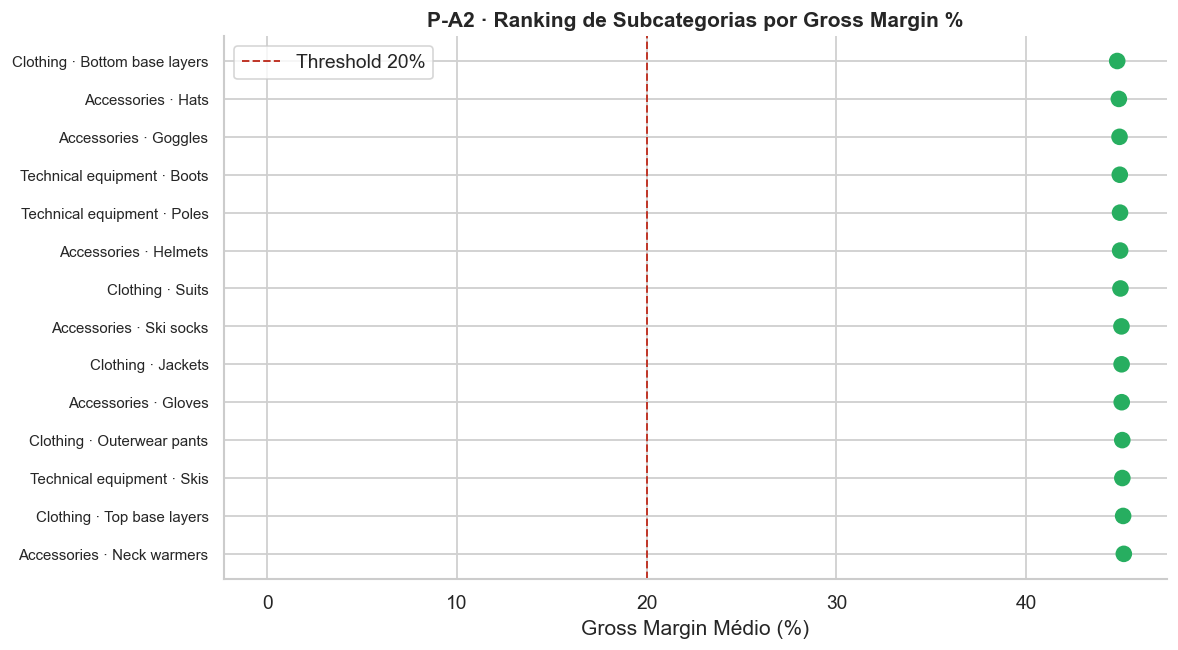

In [100]:
# ── Gráfico: Lollipop Ranking ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(5, len(pa2)*0.4)))

colors = [RED if f == 'Risco' else GREEN for f in pa2['Flag']]
y_pos  = range(len(pa2))

ax.hlines(y_pos, 0, pa2['Margin_pct'], color='lightgrey', linewidth=1)
ax.scatter(pa2['Margin_pct'], y_pos, color=colors, s=80, zorder=3)
ax.axvline(MARGIN_THRESHOLD, color=RED, linestyle='--', linewidth=1.2, label=f'Threshold {MARGIN_THRESHOLD}%')

ax.set_yticks(list(y_pos))
ax.set_yticklabels([f"{r['Main_Category']} · {r['Subcategory']}" for _, r in pa2.iterrows()], fontsize=9)
ax.set_xlabel('Gross Margin Médio (%)')
ax.set_title('P-A2 · Ranking de Subcategorias por Gross Margin %', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('PA2_ranking_subcategorias.png', bbox_inches='tight')
plt.show()

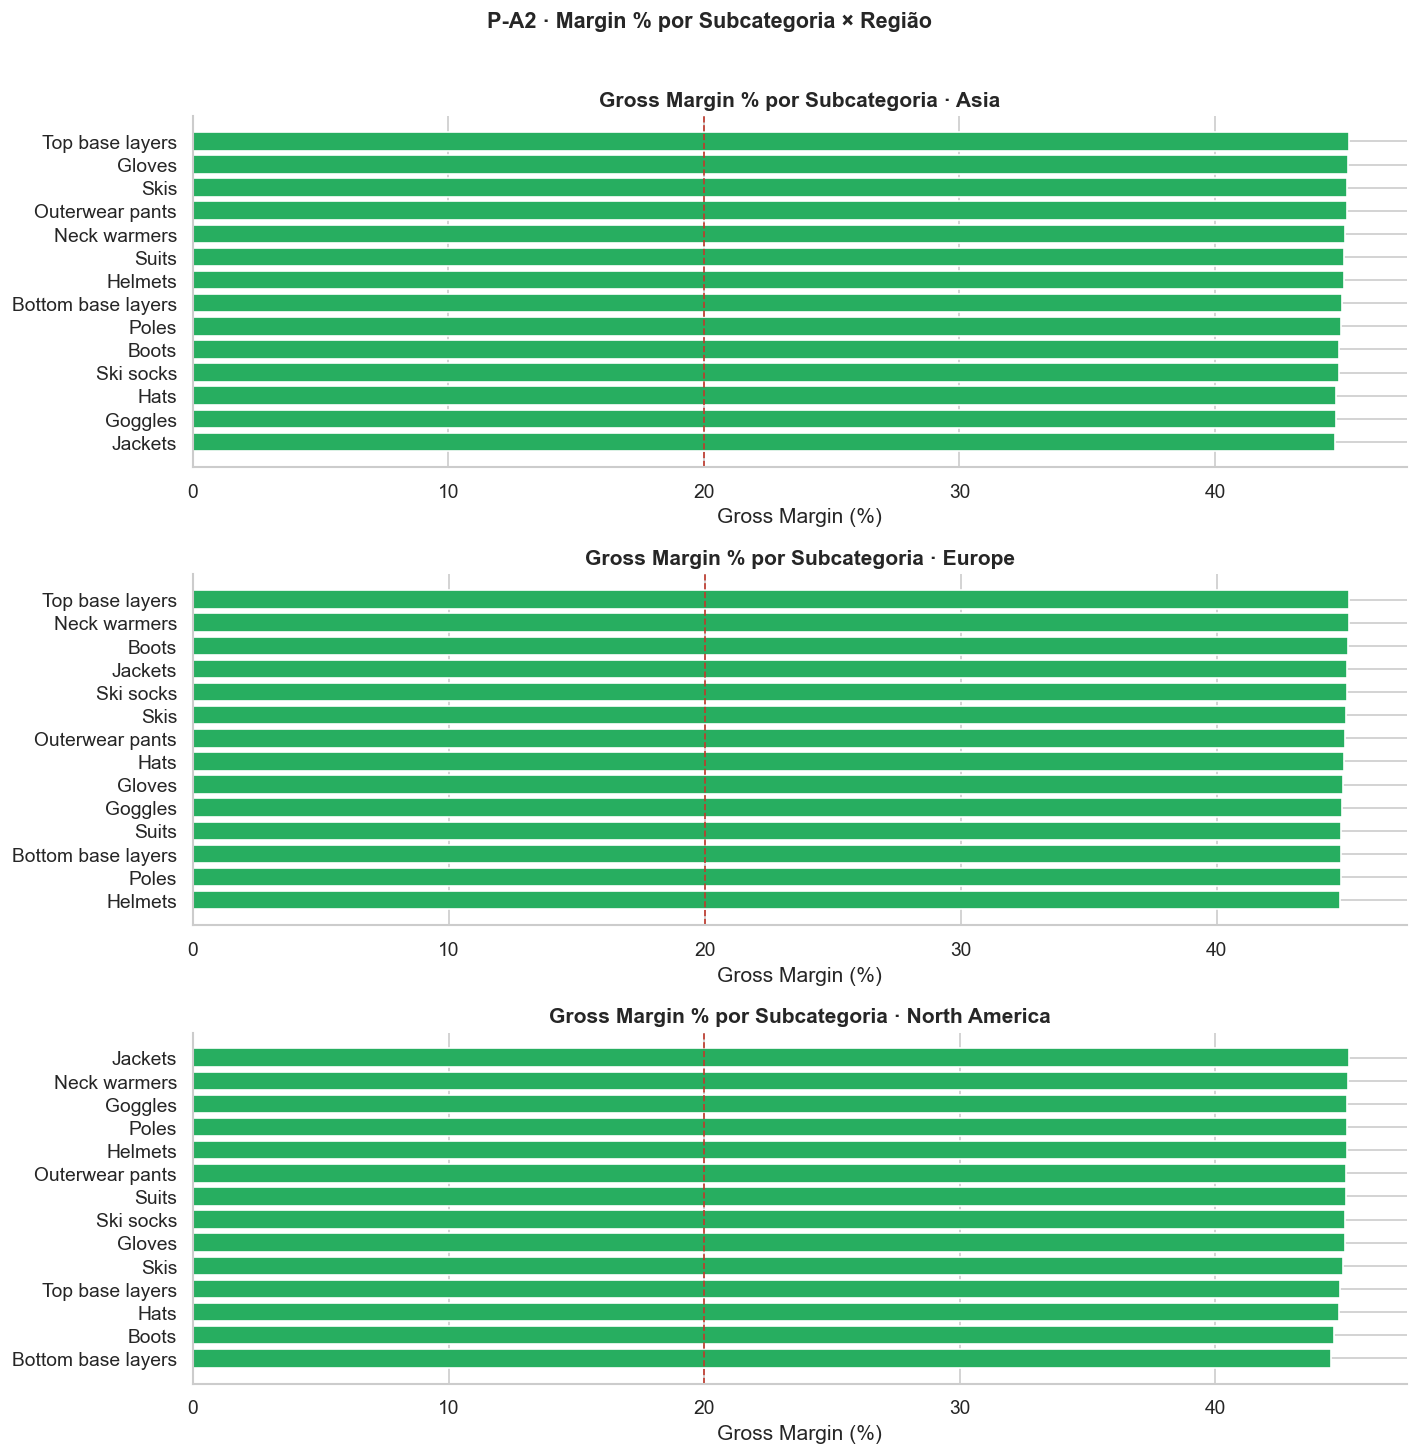

In [101]:
# ── Top 5 e Bottom 5 por Região ───────────────────────────────────────────────
pa2_reg = (
    df.groupby(['Region', 'Main_Category', 'Subcategory'])
    .agg(
        Revenue    = ('Sales_Price', 'sum'),
        GP         = ('GP', 'sum'),
        Margin_pct = ('Gross_Margin', 'mean'),
        Volume     = ('Sales_Order_ID', 'count'),
    )
    .reset_index()
)

regions = pa2_reg['Region'].unique()
fig, axes = plt.subplots(len(regions), 1, figsize=(12, 4*len(regions)))
if len(regions) == 1: axes = [axes]

for ax, reg in zip(axes, regions):
    sub = pa2_reg[pa2_reg['Region'] == reg].sort_values('Margin_pct')
    colors = [RED if m < MARGIN_THRESHOLD else GREEN for m in sub['Margin_pct']]
    ax.barh(sub['Subcategory'], sub['Margin_pct'], color=colors, edgecolor='white')
    ax.axvline(MARGIN_THRESHOLD, color=RED, linestyle='--', linewidth=1)
    ax.set_title(f'Gross Margin % por Subcategoria · {reg}', fontweight='bold')
    ax.set_xlabel('Gross Margin (%)')

plt.suptitle('P-A2 · Margin % por Subcategoria × Região', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('PA2_margin_regiao.png', bbox_inches='tight')
plt.show()

---
## 4 · P-A3 · Production Cost Ratio por Subcategoria

In [102]:
pa3 = (
    df.groupby(['Main_Category', 'Subcategory'])
    .agg(
        Avg_Price      = ('Sales_Price', 'mean'),
        Avg_Prod_Cost  = ('Production_Cost', 'mean'),
        Avg_Cost_Ratio = ('Cost_Ratio', 'mean'),
        Volume         = ('Sales_Order_ID', 'count'),
    )
    .reset_index()
    .sort_values('Avg_Cost_Ratio', ascending=False)
)

COST_THRESHOLD = 70  # % — custo de produção excessivo
pa3['Alerta'] = pa3['Avg_Cost_Ratio'] > COST_THRESHOLD

print(f'Subcategorias com Cost Ratio > {COST_THRESHOLD}%:')
display(pa3[pa3['Alerta']][['Main_Category','Subcategory','Avg_Price','Avg_Prod_Cost','Avg_Cost_Ratio']].round(2))

Subcategorias com Cost Ratio > 70%:


,Main_Category,Subcategory,Avg_Price,Avg_Prod_Cost,Avg_Cost_Ratio


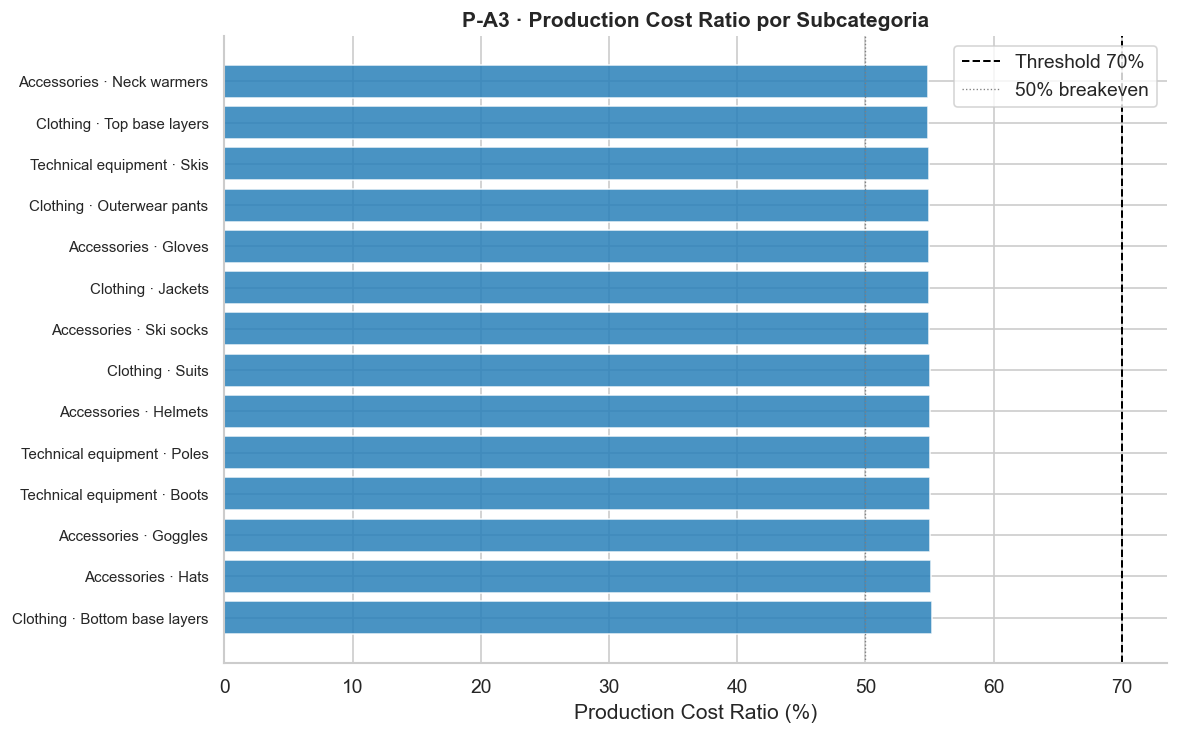

In [103]:
# ── Gráfico: Diverging bar – custo vs margem ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, max(5, len(pa3)*0.45)))

y = range(len(pa3))
colors = [RED if a else BLUE for a in pa3['Alerta']]

ax.barh(list(y), pa3['Avg_Cost_Ratio'], color=colors, edgecolor='white', alpha=0.85)
ax.axvline(COST_THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold {COST_THRESHOLD}%')
ax.axvline(50, color='grey', linestyle=':', linewidth=0.8, label='50% breakeven')

ax.set_yticks(list(y))
ax.set_yticklabels([f"{r['Main_Category']} · {r['Subcategory']}" for _, r in pa3.iterrows()], fontsize=9)
ax.set_xlabel('Production Cost Ratio (%)')
ax.set_title('P-A3 · Production Cost Ratio por Subcategoria', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('PA3_cost_ratio.png', bbox_inches='tight')
plt.show()

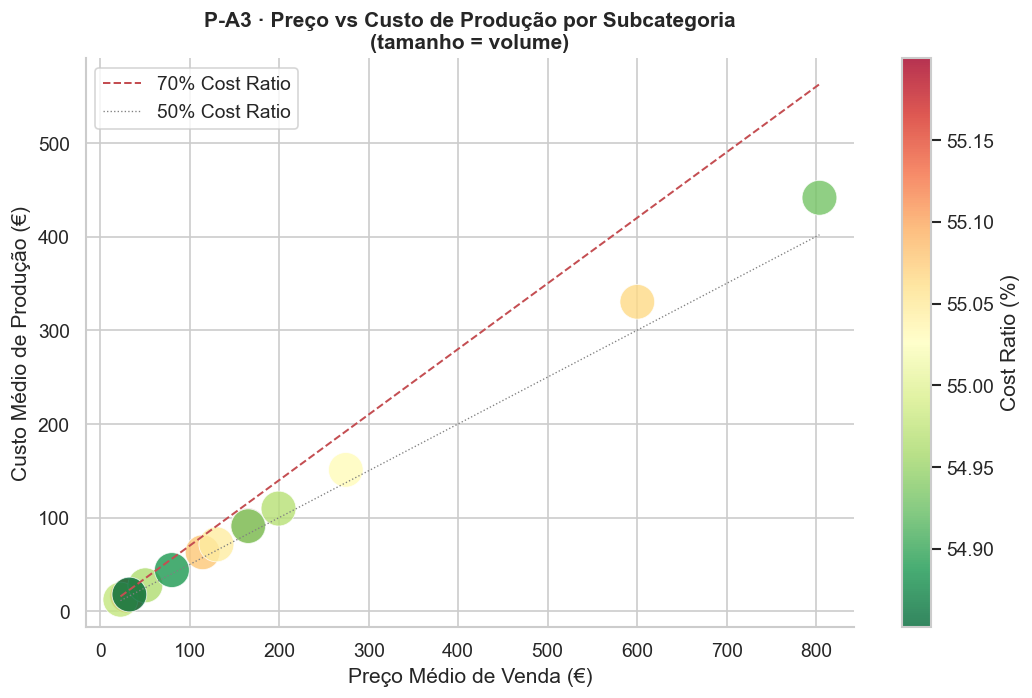

In [104]:
# ── Scatter: Avg Price vs Avg Production Cost por Subcategoria ─────────────────
fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    pa3['Avg_Price'], pa3['Avg_Prod_Cost'],
    c=pa3['Avg_Cost_Ratio'], cmap='RdYlGn_r',
    s=pa3['Volume']/pa3['Volume'].max()*400 + 40,
    alpha=0.8, edgecolors='white', linewidth=0.5
)
plt.colorbar(sc, ax=ax, label='Cost Ratio (%)')

# linha de 70% cost ratio
x_range = np.linspace(pa3['Avg_Price'].min(), pa3['Avg_Price'].max(), 100)
ax.plot(x_range, x_range * COST_THRESHOLD/100, 'r--', linewidth=1.2, label=f'{COST_THRESHOLD}% Cost Ratio')
ax.plot(x_range, x_range * 0.5, 'grey', linestyle=':', linewidth=0.8, label='50% Cost Ratio')

for _, row in pa3[pa3['Alerta']].iterrows():
    ax.annotate(row['Subcategory'], (row['Avg_Price'], row['Avg_Prod_Cost']),
                fontsize=8, color=RED, ha='left', va='bottom')

ax.set_xlabel('Preço Médio de Venda (€)')
ax.set_ylabel('Custo Médio de Produção (€)')
ax.set_title('P-A3 · Preço vs Custo de Produção por Subcategoria\n(tamanho = volume)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('PA3_scatter_preco_custo.png', bbox_inches='tight')
plt.show()

---
## 5 · P-B1 · Variação de Sales_Price pelo Mesmo Produto entre Países

In [105]:
# Preço médio por produto × país
pb1_raw = (
    df.groupby(['Product_ID', 'Product_Name', 'Main_Category', 'Subcategory', 'Country'])['Sales_Price']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'Avg_Price', 'std': 'Std_Price', 'count': 'Orders'})
)

# Apenas produtos vendidos em ≥ 2 países
n_countries = pb1_raw.groupby('Product_ID')['Country'].nunique()
multi = n_countries[n_countries >= 2].index
pb1 = pb1_raw[pb1_raw['Product_ID'].isin(multi)].copy()

# Amplitude de preço por produto (Max - Min across countries)
pb1_spread = (
    pb1.groupby(['Product_ID', 'Product_Name', 'Main_Category', 'Subcategory'])
    .agg(
        Min_Price    = ('Avg_Price', 'min'),
        Max_Price    = ('Avg_Price', 'max'),
        N_Countries  = ('Country', 'nunique'),
        Avg_Price    = ('Avg_Price', 'mean'),
    )
    .reset_index()
)
pb1_spread['Price_Range']   = pb1_spread['Max_Price'] - pb1_spread['Min_Price']
pb1_spread['Range_pct']     = pb1_spread['Price_Range'] / pb1_spread['Avg_Price'] * 100
pb1_spread = pb1_spread.sort_values('Range_pct', ascending=False)

print(f'Produtos vendidos em ≥ 2 países: {len(pb1_spread)}')
pb1_spread.head(10)

Produtos vendidos em ≥ 2 países: 6842


,Product_ID,Product_Name,Main_Category,Subcategory,Min_Price,Max_Price,N_Countries,Avg_Price,Price_Range,Range_pct
1148,CBEBLBX731,Elite Base Layer Bottom XS Orange,Clothing,Bottom base layers,32.62,269.77,4,112.532500,237.15,210.739120
1879,CBXFBMR780,X Fleece Bottom M Red,Clothing,Bottom base layers,30.76,279.93,6,118.434167,249.17,210.386924
1635,CBSTBSG606,Sport Thermal Bottom S Green,Clothing,Bottom base layers,32.52,265.12,4,110.562500,232.60,210.378745
1884,CBXFBSG496,X Fleece Bottom S Green,Clothing,Bottom base layers,30.58,287.82,3,131.513333,257.24,195.599939
1394,CBPFBMR186,Pro Fleece Bottom M Red,Clothing,Bottom base layers,39.79,273.32,4,122.400000,233.53,190.792484
1509,CBPTBXG677,Plus Thermal Bottom XS Green,Clothing,Bottom base layers,40.49,295.39,4,136.335000,254.90,186.965930
1070,CBBLBLW918,Base Layer Bottom L White,Clothing,Bottom base layers,30.30,298.88,11,143.871485,268.58,186.680495
1861,CBXBLBX659,X Base Layer Bottom XS Yellow,Clothing,Bottom base layers,33.08,191.43,4,85.437500,158.35,185.340161
1199,CBETBLG844,Elite Thermal Bottom L Green,Clothing,Bottom base layers,33.40,285.35,5,136.235333,251.95,184.937339
1366,CBPBLBX916,Plus Base Layer Bottom XXL Green,Clothing,Bottom base layers,35.83,291.81,4,140.545000,255.98,182.133836


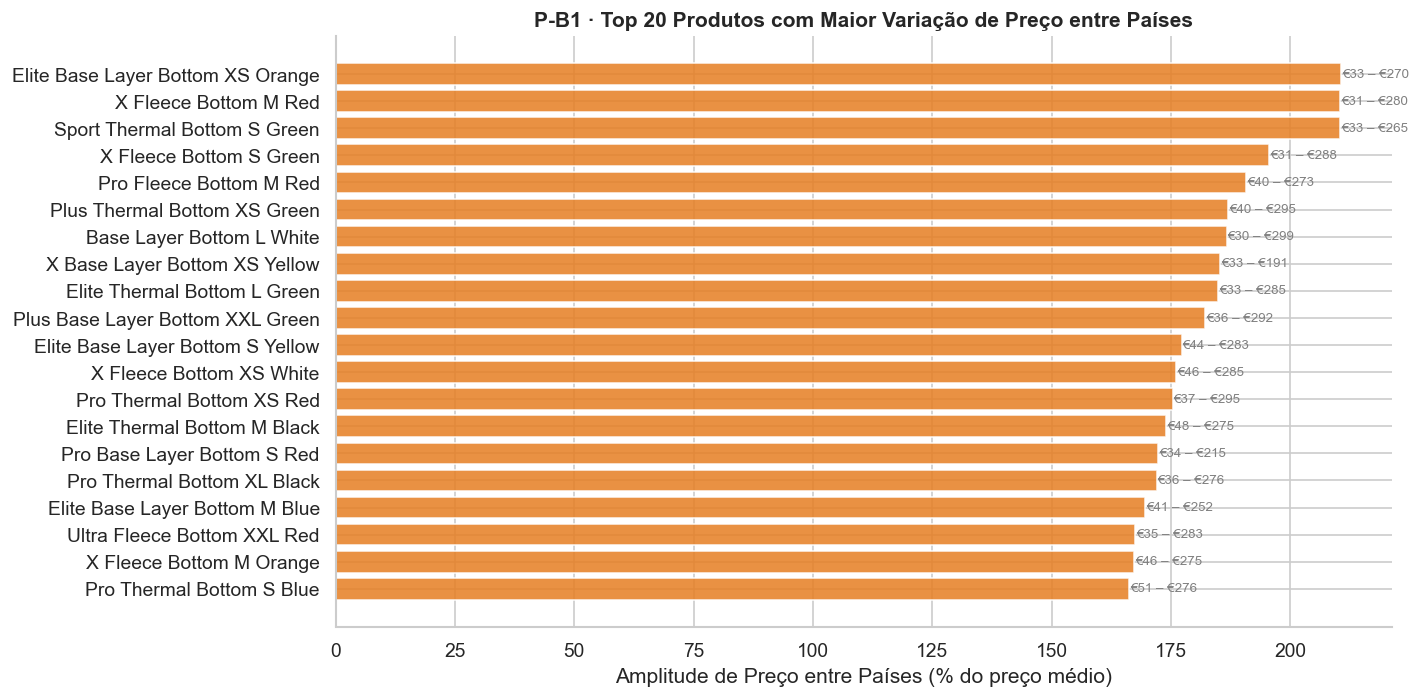

In [106]:
# ── Top 20 produtos com maior dispersão de preço entre países ─────────────────
top20 = pb1_spread.head(20)

fig, ax = plt.subplots(figsize=(12, 6))

ax.barh(top20['Product_Name'], top20['Range_pct'], color=ORANGE, edgecolor='white', alpha=0.85)
ax.set_xlabel('Amplitude de Preço entre Países (% do preço médio)')
ax.set_title('P-B1 · Top 20 Produtos com Maior Variação de Preço entre Países', fontweight='bold')
ax.invert_yaxis()

# Anotações
for i, (_, row) in enumerate(top20.iterrows()):
    ax.text(row['Range_pct']+0.2, i, f"€{row['Min_Price']:.0f} – €{row['Max_Price']:.0f}",
            va='center', fontsize=8, color='grey')

plt.tight_layout()
plt.savefig('PB1_variacao_preco_paises.png', bbox_inches='tight')
plt.show()

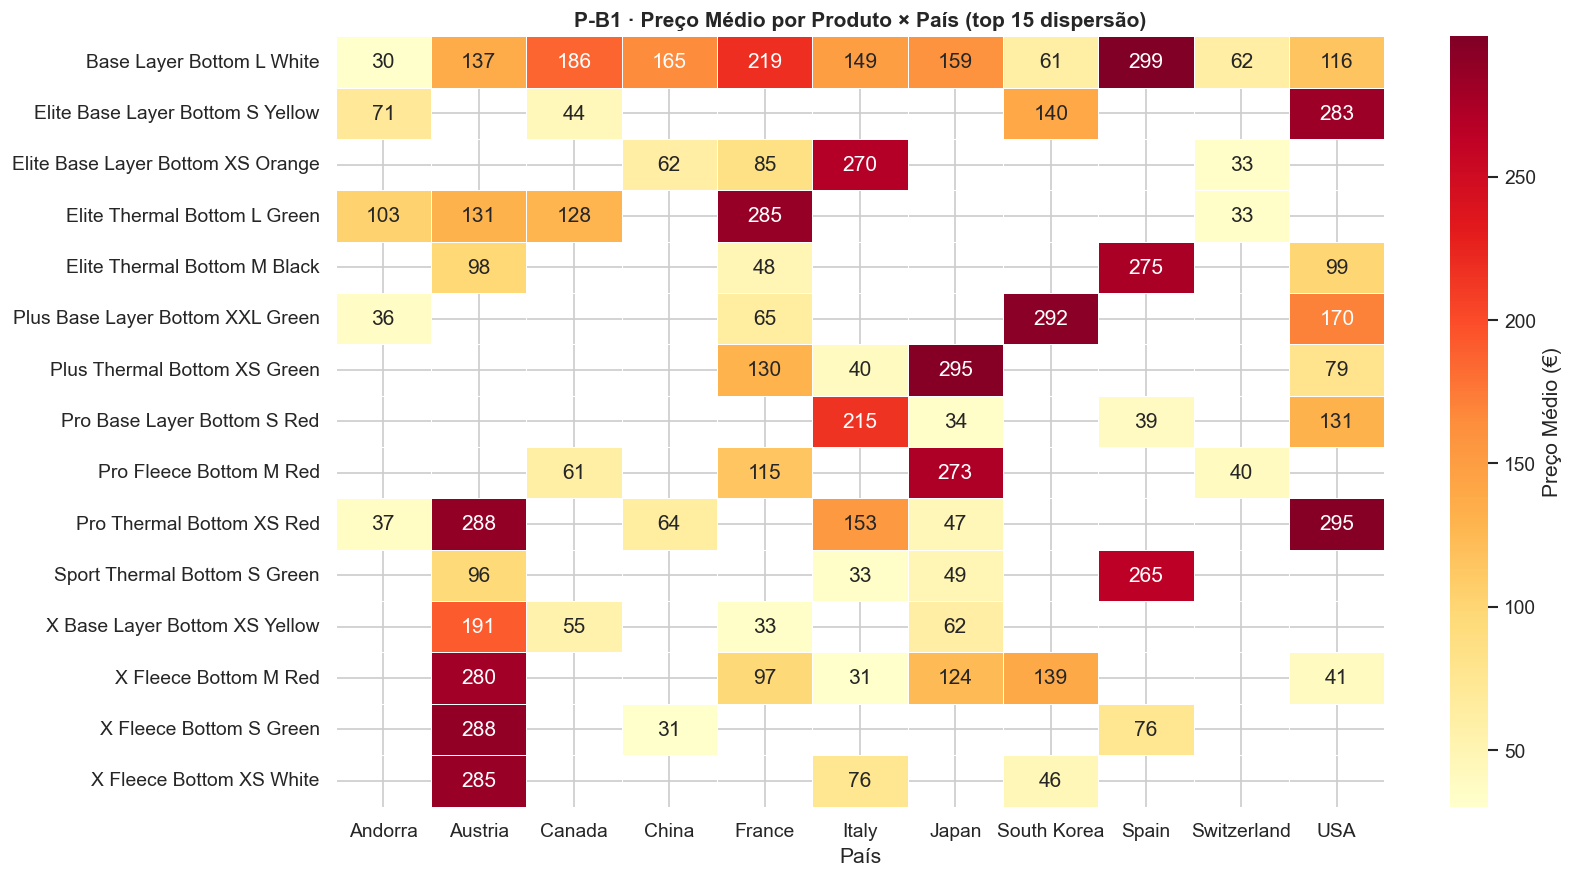

In [107]:
# ── Heatmap: Preço Médio por Produto × País (top 15 produtos com maior dispersão) ──
top15_ids = pb1_spread.head(15)['Product_ID'].tolist()
hm_data   = pb1[pb1['Product_ID'].isin(top15_ids)].pivot_table(
    index='Product_Name', columns='Country', values='Avg_Price'
)

fig, ax = plt.subplots(figsize=(14, max(5, len(hm_data)*0.5)))
sns.heatmap(
    hm_data, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.3, ax=ax, cbar_kws={'label': 'Preço Médio (€)'}
)
ax.set_title('P-B1 · Preço Médio por Produto × País (top 15 dispersão)', fontweight='bold')
ax.set_xlabel('País')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('PB1_heatmap_preco_pais.png', bbox_inches='tight')
plt.show()

In [108]:
# ── CV de Preço (P05) – Incoerências intra-país ───────────────────────────────
# Produtos com CV > 5% no mesmo país indicam pricing não standardizado
CV_THRESHOLD = 5
high_cv = kpi_cv[kpi_cv['CV_pct'] > CV_THRESHOLD].sort_values('CV_pct', ascending=False)
print(f'Combinações Produto × País com CV > {CV_THRESHOLD}%: {len(high_cv)}')
display(high_cv.head(15))

Combinações Produto × País com CV > 5%: 18287


,Product_ID,Product_Name,Main_Category,Subcategory,Country,Avg_Price,Std_Price,Orders,CV_pct
10820,CBFBLO397,Fleece Bottom L Orange,Clothing,Bottom base layers,South Korea,107.020000,124.307371,4,116.153402
11000,CBFBSR124,Fleece Bottom S Red,Clothing,Bottom base layers,South Korea,128.490000,147.085772,3,114.472544
10473,CBEFBLB234,Elite Fleece Bottom L Black,Clothing,Bottom base layers,Japan,152.695000,173.135095,2,113.386224
13062,CBTBXY297,Thermal Bottom XXL Yellow,Clothing,Bottom base layers,Spain,127.620000,142.143523,3,111.380287
10568,CBEFBXG636,Elite Fleece Bottom XXL Green,Clothing,Bottom base layers,South Korea,161.510000,179.831397,2,111.343816
10605,CBEFBXY534,Elite Fleece Bottom XS Yellow,Clothing,Bottom base layers,Austria,153.075000,167.987358,2,109.741864
11235,CBFBXW835,Fleece Bottom XL White,Clothing,Bottom base layers,Andorra,131.073333,143.023328,3,109.117030
9871,CBBLBLW918,Base Layer Bottom L White,Clothing,Bottom base layers,Japan,159.320000,171.968369,2,107.938971
10298,CBBLBXY791,Base Layer Bottom XS Yellow,Clothing,Bottom base layers,South Korea,101.940000,110.000695,4,107.907293
10115,CBBLBXB994,Base Layer Bottom XL Blue,Clothing,Bottom base layers,China,135.535000,145.996337,2,107.718550


---
## 6 · P-B2 · Análise de Descontinuação por Subcategoria × País

In [109]:
# Margem e revenue por subcategoria × país
pb2 = (
    df.groupby(['Country', 'Region', 'Main_Category', 'Subcategory'])
    .agg(
        Revenue      = ('Sales_Price', 'sum'),
        GP           = ('GP', 'sum'),
        Margin_pct   = ('Gross_Margin', 'mean'),
        Volume       = ('Sales_Order_ID', 'count'),
    )
    .reset_index()
)

# Revenue total por país
rev_pais = df.groupby('Country')['Sales_Price'].sum().rename('Rev_Total_Pais')
pb2 = pb2.merge(rev_pais, on='Country')
pb2['Rev_Share_Pais'] = pb2['Revenue'] / pb2['Rev_Total_Pais'] * 100

# Flag de candidatura a descontinuação: margem baixa E revenue share baixo
pb2['Candidato_Desc'] = (pb2['Margin_pct'] < MARGIN_THRESHOLD) & (pb2['Rev_Share_Pais'] < 5)

print(f'Candidatos a descontinuação (Margin < {MARGIN_THRESHOLD}% E Rev_Share < 5%):')
display(pb2[pb2['Candidato_Desc']].sort_values('Margin_pct')[[
    'Country','Main_Category','Subcategory','Revenue','Margin_pct','Rev_Share_Pais','GP'
]].round(2))

Candidatos a descontinuação (Margin < 20% E Rev_Share < 5%):


,Country,Main_Category,Subcategory,Revenue,Margin_pct,Rev_Share_Pais,GP


In [110]:
# ── Simulação de impacto: descontinuar subcategorias com Margin < threshold ────
sub_risco = pa2[pa2['Flag'] == 'Risco']['Subcategory'].tolist()

if sub_risco:
    atual = df.groupby('Country').agg(
        GP_Atual = ('GP', 'sum'),
        Rev_Atual = ('Sales_Price', 'sum')
    )
    sem_risco = df[~df['Subcategory'].isin(sub_risco)].groupby('Country').agg(
        GP_Novo = ('GP', 'sum'),
        Rev_Novo = ('Sales_Price', 'sum')
    )
    sim = atual.join(sem_risco)
    sim['Delta_GP']     = sim['GP_Novo'] - sim['GP_Atual']
    sim['Delta_GP_pct'] = sim['Delta_GP'] / sim['GP_Atual'].abs() * 100
    sim['Margin_Atual'] = sim['GP_Atual'] / sim['Rev_Atual'] * 100
    sim['Margin_Nova']  = sim['GP_Novo'] / sim['Rev_Novo'] * 100
    sim['Delta_Margin'] = sim['Margin_Nova'] - sim['Margin_Atual']

    print('Simulação: impacto de descontinuar subcategorias com Margin < threshold')
    display(sim[['GP_Atual','GP_Novo','Delta_GP','Margin_Atual','Margin_Nova','Delta_Margin']].round(2))
else:
    print('Nenhuma subcategoria abaixo do threshold de margem.')

Nenhuma subcategoria abaixo do threshold de margem.


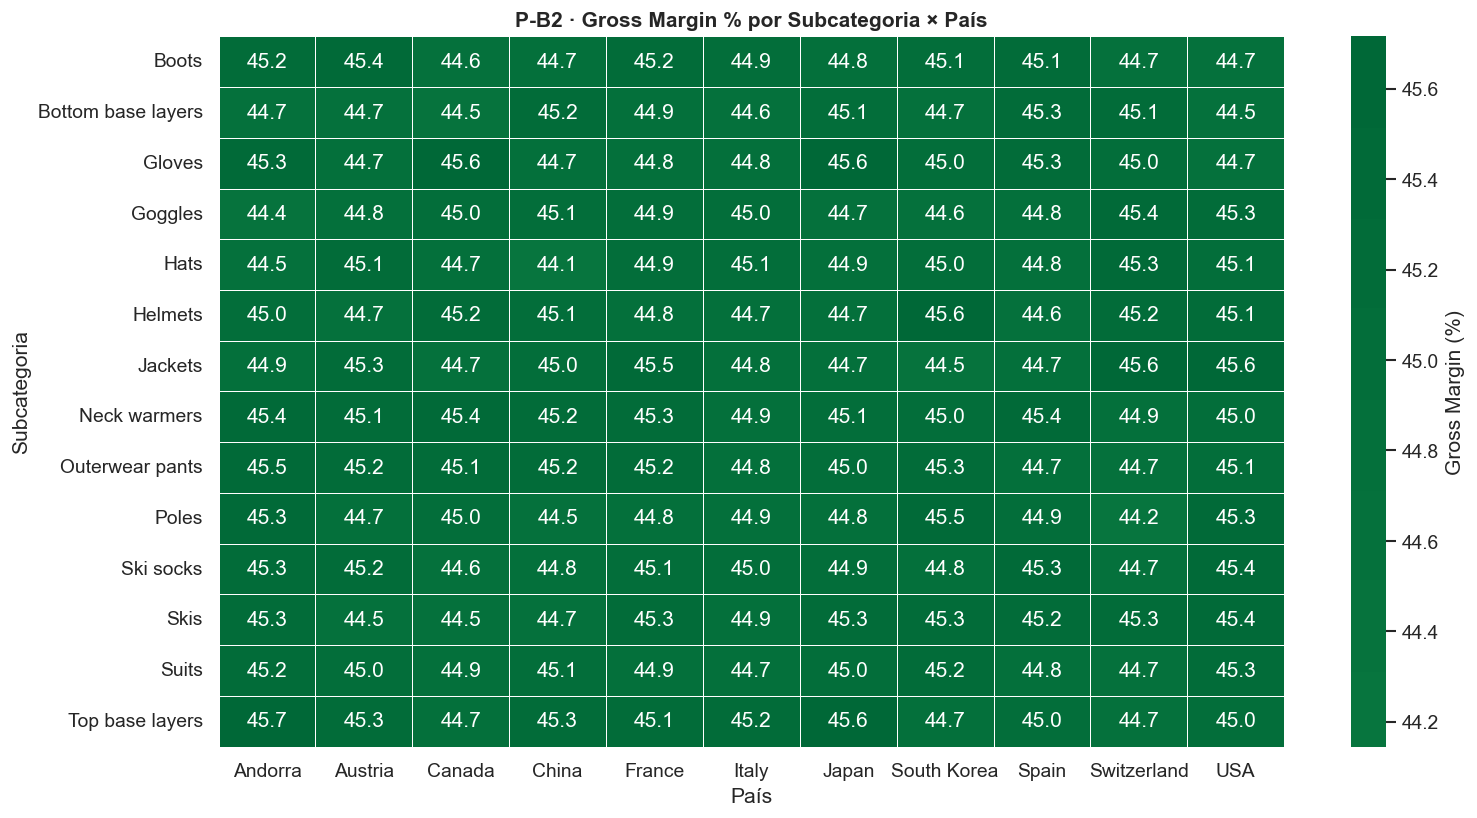

In [111]:
# ── Heatmap: Margin % por Subcategoria × País ─────────────────────────────────
hm_pb2 = pb2.pivot_table(index='Subcategory', columns='Country', values='Margin_pct', aggfunc='mean')

fig, ax = plt.subplots(figsize=(max(10, len(hm_pb2.columns)*1.2), max(6, len(hm_pb2)*0.5)))
sns.heatmap(
    hm_pb2, annot=True, fmt='.1f', cmap='RdYlGn', center=MARGIN_THRESHOLD,
    linewidths=0.3, ax=ax, cbar_kws={'label': 'Gross Margin (%)'}
)
ax.set_title('P-B2 · Gross Margin % por Subcategoria × País', fontweight='bold')
ax.set_xlabel('País')
ax.set_ylabel('Subcategoria')
plt.tight_layout()
plt.savefig('PB2_heatmap_margin_pais.png', bbox_inches='tight')
plt.show()

---
## 7 · Tipo de Produto com Maior Tempo de Entrega

In [112]:
# Apenas registos com Due_Date preenchida
df_del = df[df['Delivery_Days'].notna() & (df['Delivery_Days'] >= 0)].copy()
print(f'Registos com Delivery_Days válido: {len(df_del):,} de {len(df):,}')

del_cat = (
    df_del.groupby(['Main_Category', 'Subcategory'])['Delivery_Days']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'Avg_Days', 'median': 'Med_Days', 'std': 'Std_Days', 'count': 'N'})
    .sort_values('Avg_Days', ascending=False)
)

display(del_cat.head(10))

Registos com Delivery_Days válido: 26,480 de 147,511


,Main_Category,Subcategory,Avg_Days,Med_Days,Std_Days,N
11,Technical equipment,Boots,5.069513,5.0,1.410757,1827
1,Accessories,Goggles,5.062081,5.0,1.407095,1788
3,Accessories,Helmets,5.023971,5.0,1.416957,1919
9,Clothing,Suits,5.021345,5.0,1.398486,1874
8,Clothing,Outerwear pants,5.009630,5.0,1.398495,1973
4,Accessories,Neck warmers,5.003786,5.0,1.405958,1849
7,Clothing,Jackets,4.998956,5.0,1.386605,1915
10,Clothing,Top base layers,4.996899,5.0,1.425862,1935
13,Technical equipment,Skis,4.994786,5.0,1.418256,1918
6,Clothing,Bottom base layers,4.986631,5.0,1.430140,1870


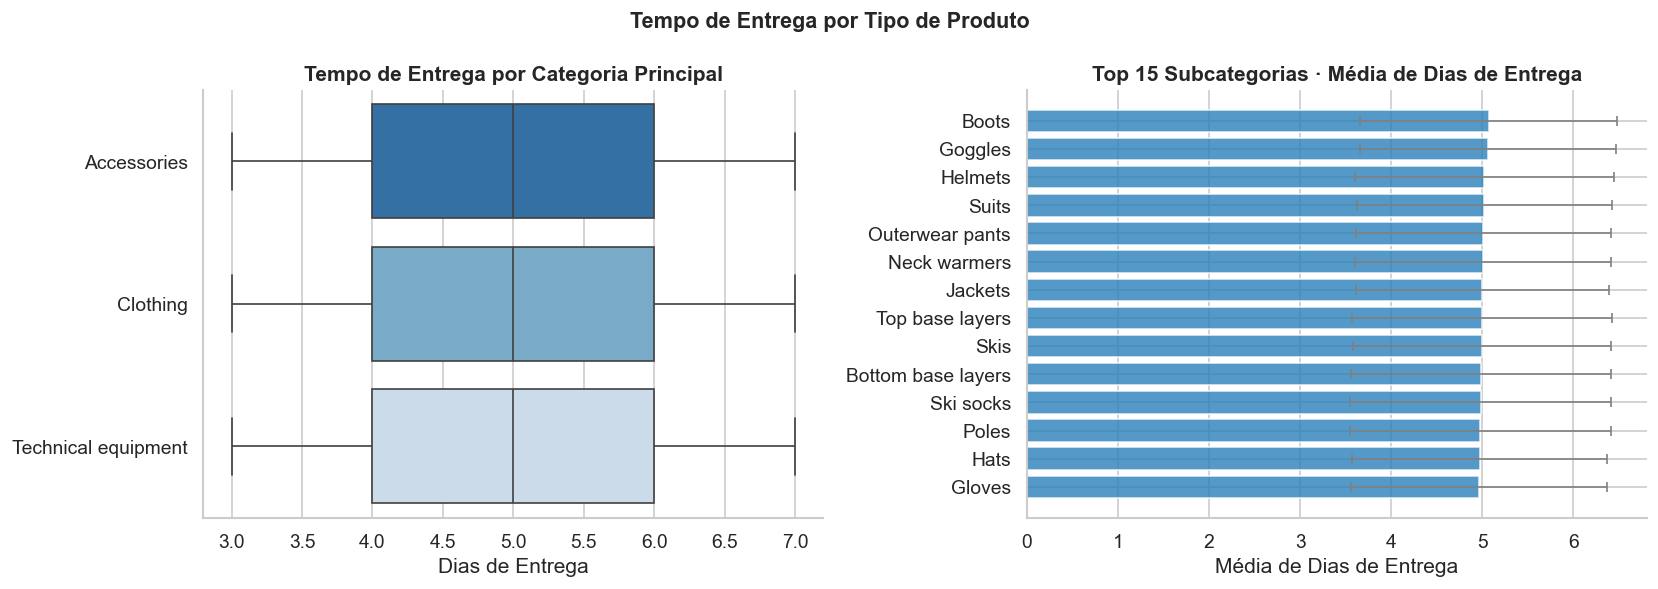

In [113]:
# ── Gráfico: Boxplot de Delivery Days por Main Category ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Por Main Category
order_cat = df_del.groupby('Main_Category')['Delivery_Days'].median().sort_values(ascending=False).index
sns.boxplot(data=df_del, x='Delivery_Days', y='Main_Category', order=order_cat,
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Tempo de Entrega por Categoria Principal', fontweight='bold')
axes[0].set_xlabel('Dias de Entrega')
axes[0].set_ylabel('')

# Por Subcategory (médias)
top_sub = del_cat.head(15)
axes[1].barh(top_sub['Subcategory'], top_sub['Avg_Days'],
             xerr=top_sub['Std_Days'], color=BLUE, alpha=0.8, edgecolor='white',
             error_kw={'elinewidth': 1, 'capsize': 3, 'ecolor': 'grey'})
axes[1].set_title('Top 15 Subcategorias · Média de Dias de Entrega', fontweight='bold')
axes[1].set_xlabel('Média de Dias de Entrega')
axes[1].invert_yaxis()

plt.suptitle('Tempo de Entrega por Tipo de Produto', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('delivery_time_produto.png', bbox_inches='tight')
plt.show()

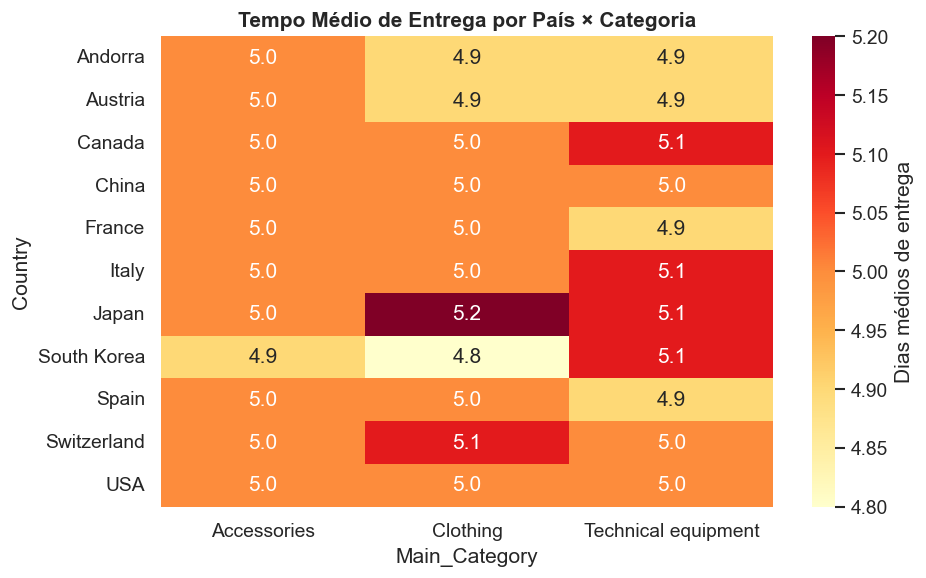

In [114]:
# ── Delivery Days por País × Categoria ────────────────────────────────────────
del_pais = (
    df_del.groupby(['Country', 'Main_Category'])['Delivery_Days']
    .mean().unstack('Main_Category').round(1)
)

fig, ax = plt.subplots(figsize=(max(8, len(del_pais.columns)*1.5), max(5, len(del_pais)*0.4)))
sns.heatmap(del_pais, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Dias médios de entrega'})
ax.set_title('Tempo Médio de Entrega por País × Categoria', fontweight='bold')
plt.tight_layout()
plt.savefig('delivery_time_pais_categoria.png', bbox_inches='tight')
plt.show()

---
## 8 · Variação de Preço & Custo ao Longo do Ano (mesmo produto, mesma localidade)

In [130]:
# Preço e custo médio por produto × país × mês
ts = (
    df.groupby(['Product_ID', 'Product_Name', 'Country', 'Year', 'Month'])
    .agg(
        Avg_Price = ('Sales_Price', 'mean'),
        Avg_Cost  = ('Production_Cost', 'mean'),
        Volume    = ('Sales_Order_ID', 'count'),
    )
    .reset_index()
)

# Filtrar combinações Produto × País × Ano com ≥ 6 meses de dados
months_count = ts.groupby(['Product_ID', 'Country', 'Year'])['Month'].nunique()
valid = months_count[months_count >= 6].reset_index()
ts_valid = ts.merge(valid[['Product_ID','Country','Year']], on=['Product_ID','Country','Year'])

print(f'Combinações Produto × País × Ano com ≥ 6 meses: {len(valid)}')
ts_valid.head()

Combinações Produto × País × Ano com ≥ 6 meses: 2316


,Product_ID,Product_Name,Country,Year,Month,Avg_Price,Avg_Cost,Volume
0,AGIGB508,Insulated Gloves Blue,Austria,2025,2,33.040,14.73,1
1,AGIGB508,Insulated Gloves Blue,Austria,2025,3,61.970,28.71,1
2,AGIGB508,Insulated Gloves Blue,Austria,2025,5,71.690,45.98,1
3,AGIGB508,Insulated Gloves Blue,Austria,2025,6,57.035,30.14,2
4,AGIGB508,Insulated Gloves Blue,Austria,2025,8,34.060,20.07,2


In [131]:
# ── Variação mensal de preço: coeficiente de variação por combinação ───────────
cv_ts = (
    ts_valid.groupby(['Product_ID', 'Product_Name', 'Country', 'Year'])
    .agg(
        CV_Price = ('Avg_Price', lambda x: x.std() / x.mean() * 100 if x.mean() != 0 else np.nan),
        CV_Cost  = ('Avg_Cost',  lambda x: x.std() / x.mean() * 100 if x.mean() != 0 else np.nan),
    )
    .reset_index()
    .sort_values('CV_Price', ascending=False)
)

print('Top 10 produtos com maior variação de preço intra-anual (mesmo país):')
display(cv_ts.head(10))

Top 10 produtos com maior variação de preço intra-anual (mesmo país):


,Product_ID,Product_Name,Country,Year,CV_Price,CV_Cost
449,AGWGG625,Waterproof Gloves Gray,Italy,2024,58.840834,48.260829
1537,ASCSW728,Compression Socks White,Italy,2022,56.609721,69.241264
438,AGWGB622,Waterproof Gloves Black,Spain,2025,56.293133,54.200549
169,AGLGO536,Leather Gloves Orange,France,2022,54.175699,49.753777
1706,ASTSG728,Thermal Socks Green,Canada,2023,50.963916,43.331809
38,AGIGG744,Insulated Gloves Gray,Spain,2024,50.306328,39.504741
1645,ASMWSW157,Merino Wool Socks White,Japan,2022,50.178348,53.877968
16,AGIGB781,Insulated Gloves Black,Canada,2025,49.891828,55.863202
186,AGLGR972,Leather Gloves Red,Spain,2023,49.402023,40.872971
179,AGLGR972,Leather Gloves Red,Canada,2022,49.266747,49.371982


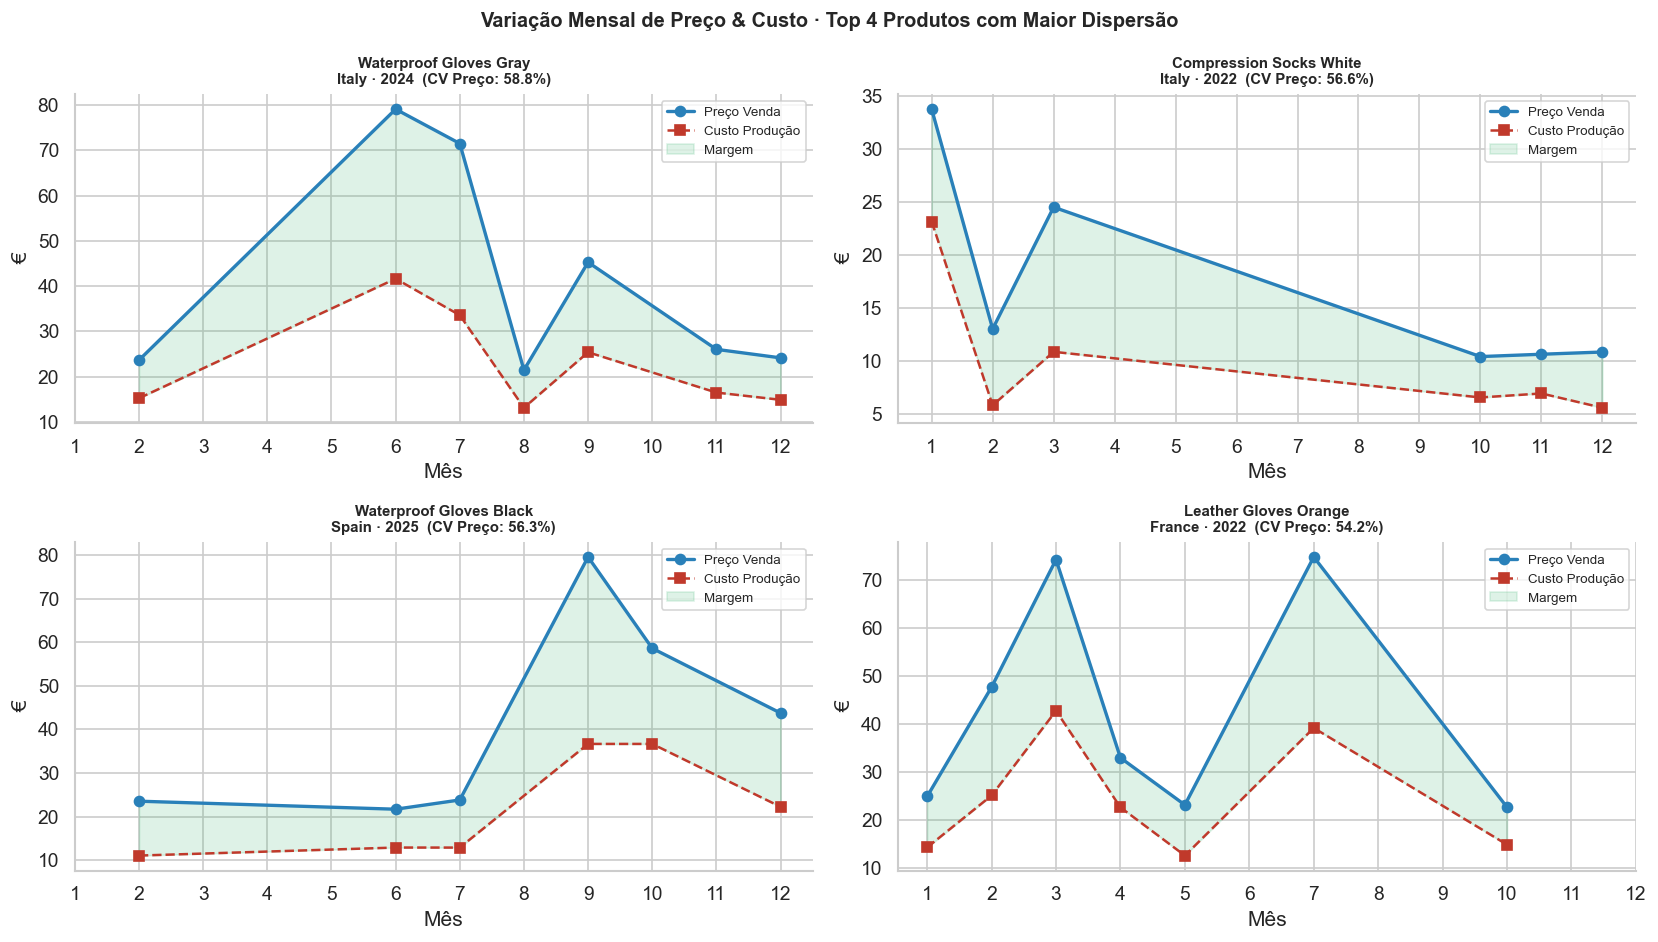

In [132]:
# ── Linha temporal dos top 4 produtos com maior variação de preço ──────────────
top4 = cv_ts.dropna(subset=['CV_Price']).head(4)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, top4.iterrows()):
    sub = ts_valid[
        (ts_valid['Product_ID'] == row['Product_ID']) &
        (ts_valid['Country']    == row['Country']) &
        (ts_valid['Year']       == row['Year'])
    ].sort_values('Month')

    ax.plot(sub['Month'], sub['Avg_Price'], 'o-', color=BLUE, label='Preço Venda', linewidth=2)
    ax.plot(sub['Month'], sub['Avg_Cost'],  's--', color=RED,  label='Custo Produção', linewidth=1.5)
    ax.fill_between(sub['Month'], sub['Avg_Cost'], sub['Avg_Price'],
                    alpha=0.15, color=GREEN, label='Margem')

    ax.set_title(f"{row['Product_Name'][:30]}\n{row['Country']} · {int(row['Year'])}  (CV Preço: {row['CV_Price']:.1f}%)",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('Mês')
    ax.set_ylabel('€')
    ax.set_xticks(range(1, 13))
    ax.legend(fontsize=8)

plt.suptitle('Variação Mensal de Preço & Custo · Top 4 Produtos com Maior Dispersão', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('variacao_preco_custo_mensal.png', bbox_inches='tight')
plt.show()

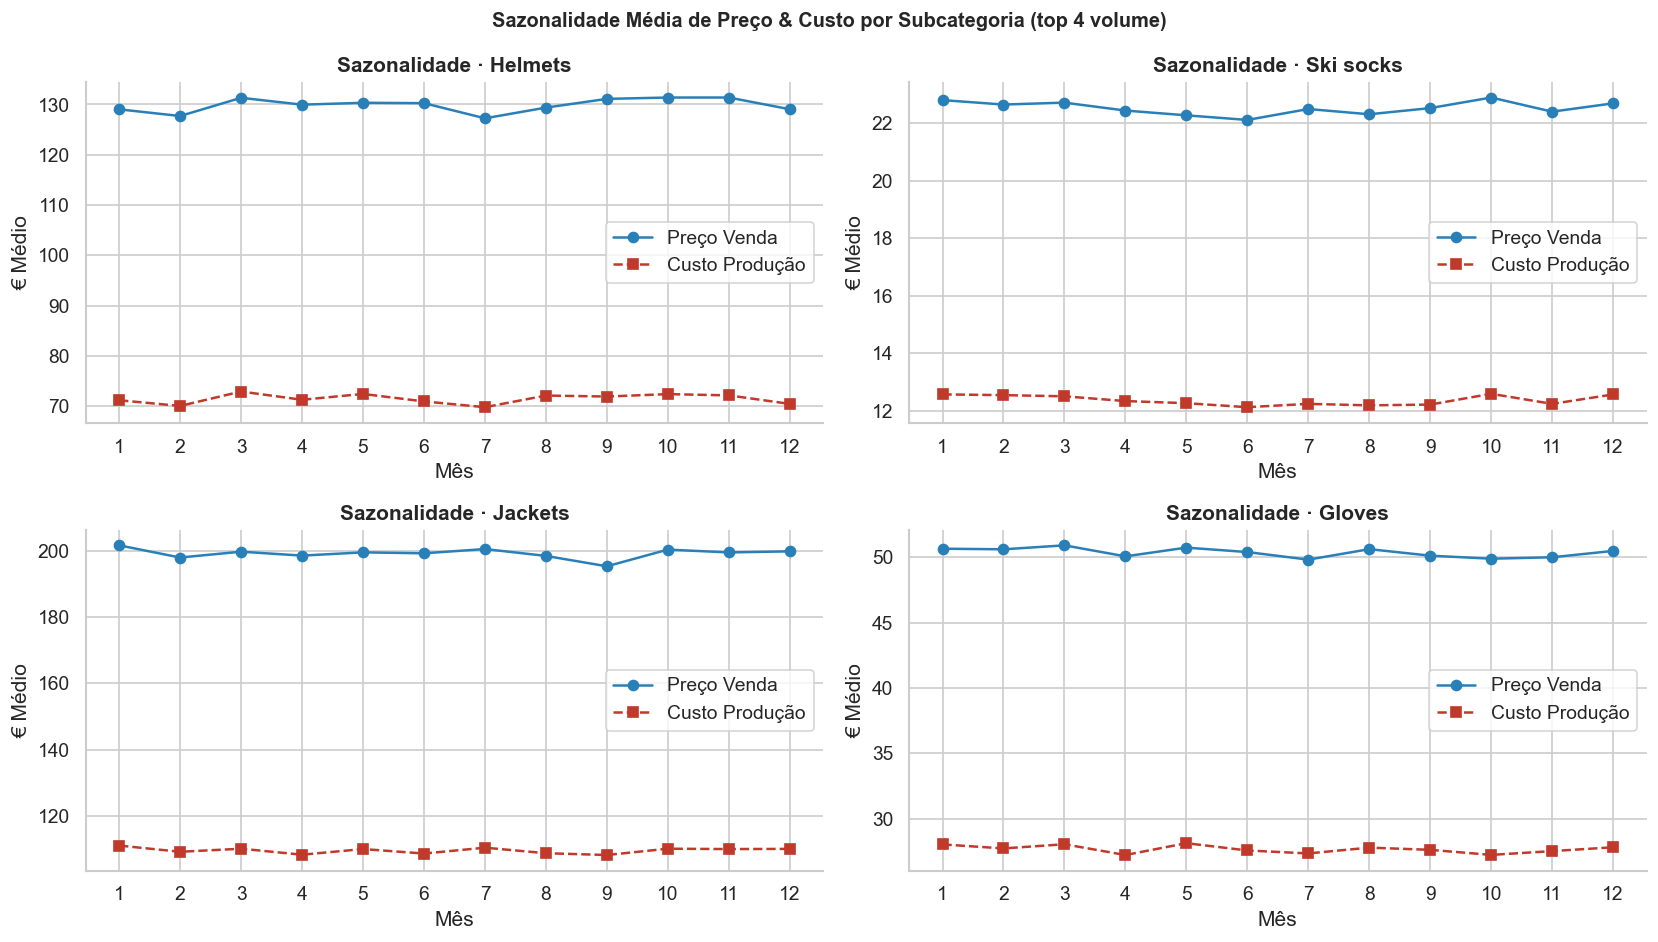

In [118]:
# ── Sazonalidade média de preço por Subcategoria ──────────────────────────────
saz = (
    df.groupby(['Subcategory', 'Month'])
    .agg(Avg_Price=('Sales_Price', 'mean'), Avg_Cost=('Production_Cost', 'mean'))
    .reset_index()
)

# Top 4 subcategorias com maior volume
top_subs = df.groupby('Subcategory')['Sales_Order_ID'].count().nlargest(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, sub_name in zip(axes, top_subs):
    s = saz[saz['Subcategory'] == sub_name].sort_values('Month')
    ax.plot(s['Month'], s['Avg_Price'], 'o-', color=BLUE, label='Preço Venda')
    ax.plot(s['Month'], s['Avg_Cost'],  's--', color=RED, label='Custo Produção')
    ax.set_title(f'Sazonalidade · {sub_name}', fontweight='bold')
    ax.set_xlabel('Mês')
    ax.set_ylabel('€ Médio')
    ax.set_xticks(range(1, 13))
    ax.legend()

plt.suptitle('Sazonalidade Média de Preço & Custo por Subcategoria (top 4 volume)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('sazonalidade_preco_custo.png', bbox_inches='tight')
plt.show()

---
## 9 · Análise por Cor de Produto dentro da Mesma Categoria

In [119]:
# Extrair cor do Product_Name (palavra(s) em maiúsculas ou após padrões comuns)
import re

COLOR_KEYWORDS = [
    'Black', 'White', 'Red', 'Blue', 'Green', 'Yellow', 'Orange', 'Purple',
    'Pink', 'Grey', 'Gray', 'Brown', 'Navy', 'Teal', 'Beige', 'Silver',
    'Gold', 'Cyan', 'Magenta', 'Coral', 'Lime', 'Indigo', 'Violet',
    'Turquoise', 'Crimson', 'Maroon', 'Olive', 'Khaki', 'Ivory'
]

pattern = r'\b(' + '|'.join(COLOR_KEYWORDS) + r')\b'

df['Color'] = df['Product_Name'].str.extract(pattern, flags=re.IGNORECASE)[0].str.title()

has_color = df['Color'].notna().sum()
print(f'Registos com cor identificada: {has_color:,} ({has_color/len(df)*100:.1f}%)')
print('\nDistribuição de cores:')
print(df['Color'].value_counts())

Registos com cor identificada: 126,507 (85.8%)

Distribuição de cores:
Color
Gray      15962
Yellow    15905
Blue      15899
Green     15872
White     15846
Red       15764
Black     15683
Orange    15576
Name: count, dtype: int64


In [120]:
df_cor = df[df['Color'].notna()].copy()

if len(df_cor) > 0:
    # Margem e volume por Cor × Categoria
    cor_cat = (
        df_cor.groupby(['Main_Category', 'Subcategory', 'Color'])
        .agg(
            Revenue    = ('Sales_Price', 'sum'),
            GP         = ('GP', 'sum'),
            Margin_pct = ('Gross_Margin', 'mean'),
            Volume     = ('Sales_Order_ID', 'count'),
        )
        .reset_index()
    )
    display(cor_cat.sort_values('Volume', ascending=False).head(15))
else:
    print('Nenhum produto com cor identificada no Product_Name. Verificar nomenclatura dos produtos.')

,Main_Category,Subcategory,Color,Revenue,GP,Margin_pct,Volume
82,Clothing,Top base layers,Gray,110822.03,49573.26,44.775201,1383
61,Clothing,Jackets,Red,274991.04,122884.70,44.733249,1375
79,Clothing,Suits,Yellow,373322.37,169119.60,45.231150,1373
45,Accessories,Ski socks,Red,30913.10,13964.44,45.005914,1371
26,Accessories,Helmets,Gray,176859.86,79276.05,44.838200,1368
30,Accessories,Helmets,White,178338.92,79828.30,44.773967,1365
44,Accessories,Ski socks,Orange,30560.08,13773.42,44.966409,1365
6,Accessories,Gloves,White,69226.14,31122.54,44.941276,1364
50,Clothing,Bottom base layers,Gray,224052.02,100136.34,44.828801,1363
8,Accessories,Goggles,Black,156907.82,70176.05,44.795869,1363


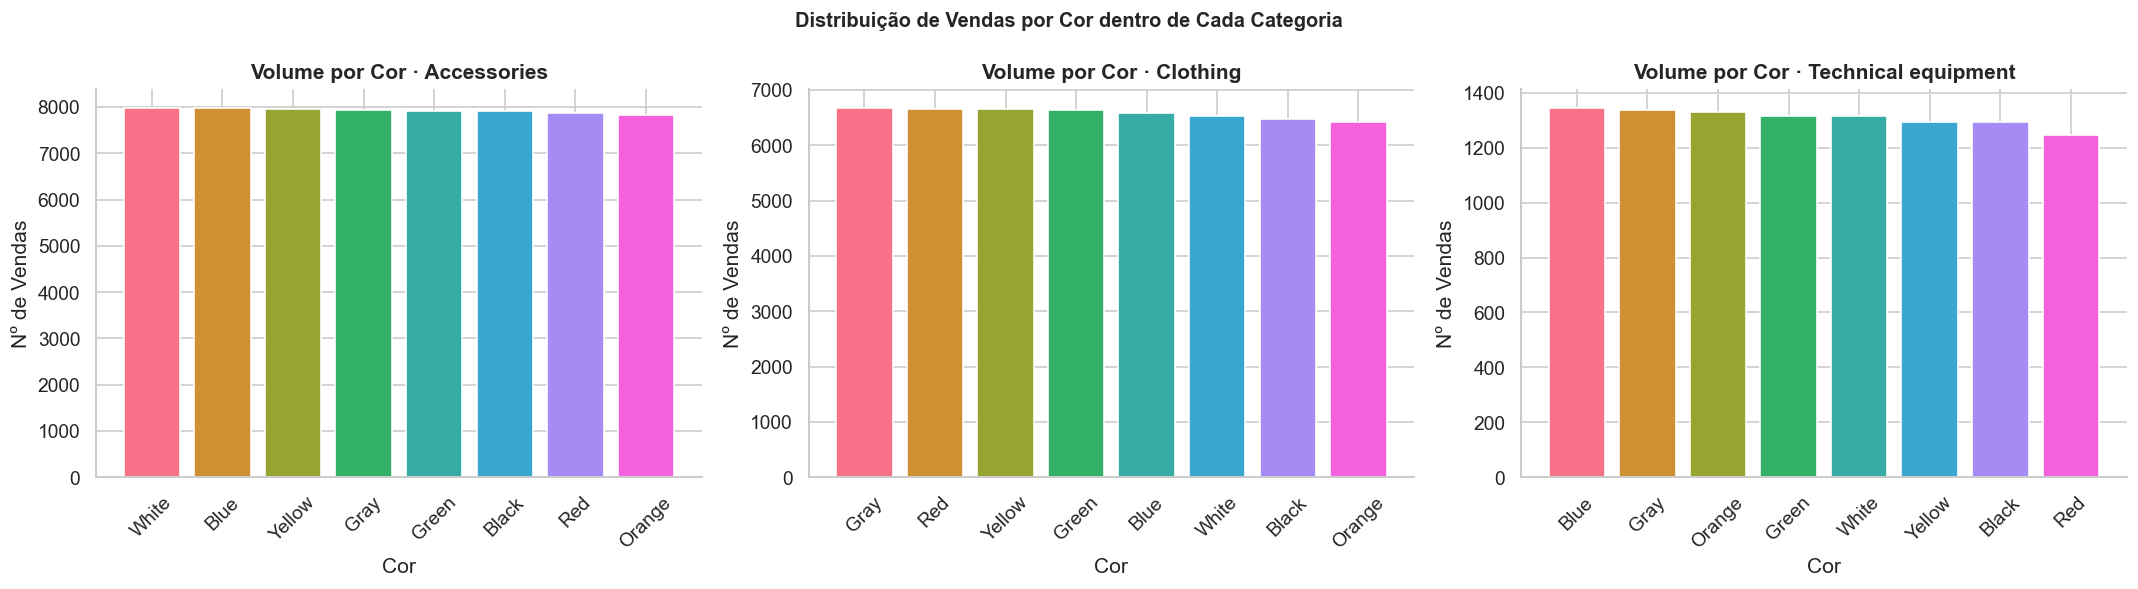

In [121]:
if len(df_cor) > 0 and df_cor['Main_Category'].nunique() > 0:
    cats_with_color = df_cor['Main_Category'].unique()

    # Filtrar categorias que realmente têm cores identificadas
    cats_with_color = [
        cat for cat in cats_with_color
        if df_cor[df_cor['Main_Category'] == cat]['Color'].notna().any()
    ]

    if not cats_with_color:
        print('Nenhuma categoria com cores identificadas.')
    else:
        fig, axes = plt.subplots(1, len(cats_with_color),
                                  figsize=(6*len(cats_with_color), 5), sharey=False)
        if len(cats_with_color) == 1:
            axes = [axes]

        for ax, cat in zip(axes, cats_with_color):
            sub = df_cor[df_cor['Main_Category'] == cat]
            color_vol = sub.groupby('Color')['Sales_Order_ID'].count().sort_values(ascending=False)

            if len(color_vol) == 0:
                ax.set_visible(False)
                continue

            palette = list(sns.color_palette('husl', len(color_vol)))
            ax.bar(color_vol.index, color_vol.values, color=palette, edgecolor='white')
            ax.set_title(f'Volume por Cor · {cat}', fontweight='bold')
            ax.set_xlabel('Cor')
            ax.set_ylabel('Nº de Vendas')
            ax.tick_params(axis='x', rotation=45)

        plt.suptitle('Distribuição de Vendas por Cor dentro de Cada Categoria',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig('cor_por_categoria.png', bbox_inches='tight')
        plt.show()

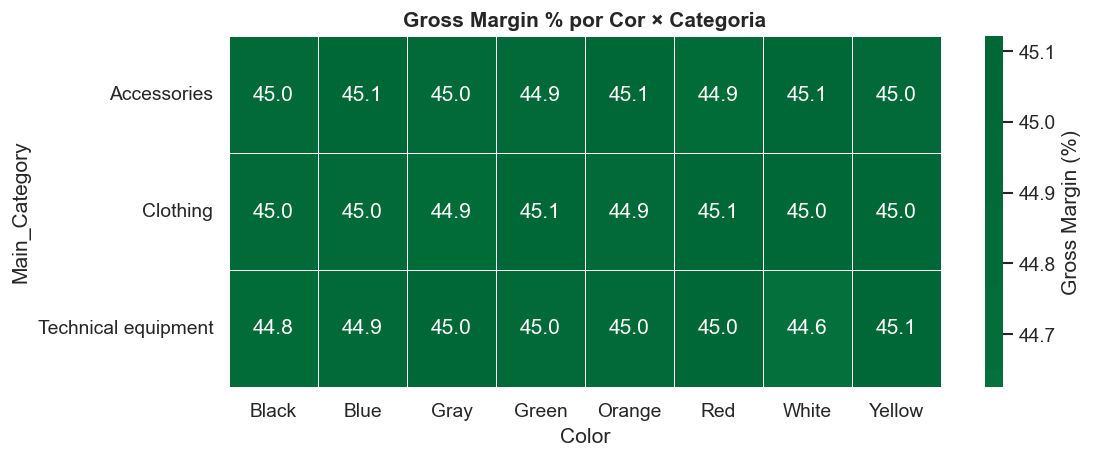

In [122]:
if len(df_cor) > 0:
    # Gross Margin % por cor dentro de cada categoria
    cor_margin = df_cor.groupby(['Main_Category', 'Color'])['Gross_Margin'].mean().unstack('Color')

    fig, ax = plt.subplots(figsize=(max(8, len(cor_margin.columns)*1.2), 4))
    sns.heatmap(cor_margin, annot=True, fmt='.1f', cmap='RdYlGn', center=30,
                linewidths=0.3, ax=ax, cbar_kws={'label': 'Gross Margin (%)'}
    )
    ax.set_title('Gross Margin % por Cor × Categoria', fontweight='bold')
    plt.tight_layout()
    plt.savefig('cor_margin_heatmap.png', bbox_inches='tight')
    plt.show()

---
## 10 · Análise Geral de Vendas por Produto

#### Agregação completa por produto
prod_summary = (
    df.groupby(['Product_ID', 'Product_Name', 'Main_Category', 'Subcategory'])
    .agg(
        Revenue      = ('Sales_Price', 'sum'),
        GP           = ('GP', 'sum'),
        Margin_pct   = ('Gross_Margin', 'mean'),
        Cost_Ratio   = ('Cost_Ratio', 'mean'),
        Volume       = ('Sales_Order_ID', 'count'),
        Avg_Price    = ('Sales_Price', 'mean'),
        Avg_Cost     = ('Production_Cost', 'mean'),
        N_Countries  = ('Country', 'nunique'),
        N_Regions    = ('Region', 'nunique'),
    )
    .reset_index()
    .sort_values('Revenue', ascending=False)
)

prod_summary['Rev_Share_pct'] = prod_summary['Revenue'] / prod_summary['Revenue'].sum() * 100
prod_summary['Rev_Cum_pct']   = prod_summary['Rev_Share_pct'].cumsum()

# Pareto 80%
pareto_80 = (prod_summary['Rev_Cum_pct'] <= 80).sum()
print(f'Pareto 80%: {pareto_80} produtos geram 80% da receita total ({pareto_80/len(prod_summary)*100:.1f}% dos produtos)')
prod_summary.head(10)

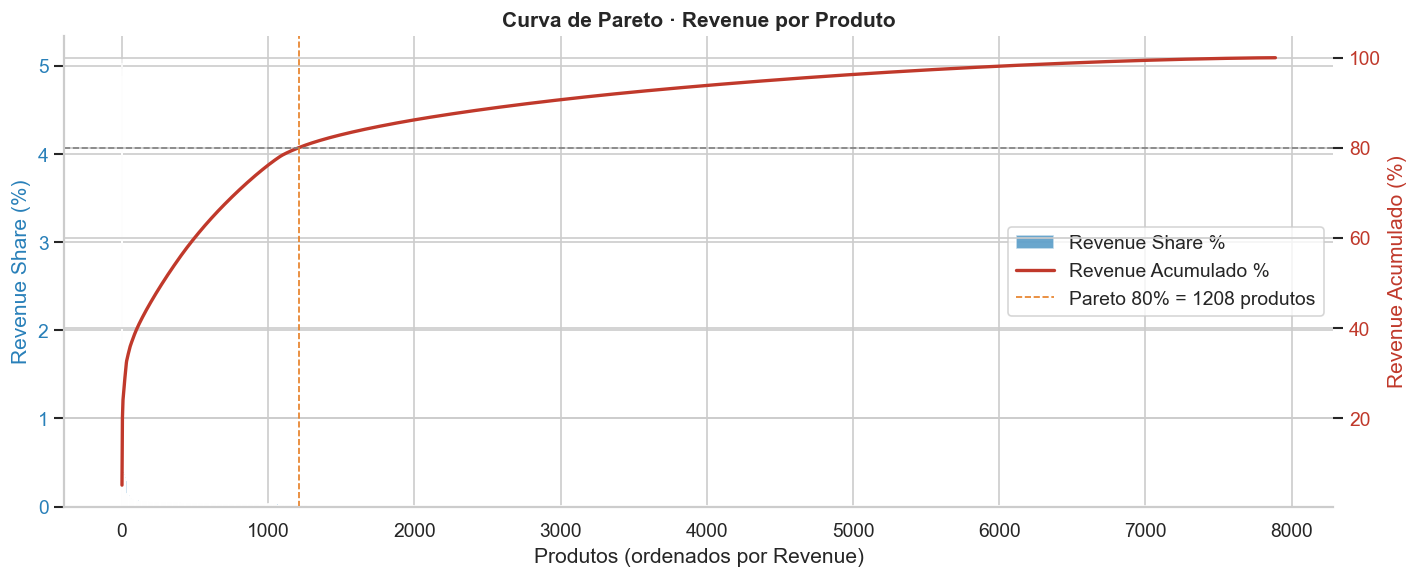

In [124]:
# ── Curva de Pareto ────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(range(len(prod_summary)), prod_summary['Rev_Share_pct'],
        color=BLUE, alpha=0.7, label='Revenue Share %')
ax1.set_xlabel('Produtos (ordenados por Revenue)')
ax1.set_ylabel('Revenue Share (%)', color=BLUE)
ax1.tick_params(axis='y', labelcolor=BLUE)

ax2 = ax1.twinx()
ax2.plot(range(len(prod_summary)), prod_summary['Rev_Cum_pct'],
         color=RED, linewidth=2, label='Revenue Acumulado %')
ax2.axhline(80, color='grey', linestyle='--', linewidth=1)
ax2.axvline(pareto_80, color=ORANGE, linestyle='--', linewidth=1, label=f'Pareto 80% = {pareto_80} produtos')
ax2.set_ylabel('Revenue Acumulado (%)', color=RED)
ax2.tick_params(axis='y', labelcolor=RED)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='center right')
ax1.set_title('Curva de Pareto · Revenue por Produto', fontweight='bold')

plt.tight_layout()
plt.savefig('pareto_produtos.png', bbox_inches='tight')
plt.show()

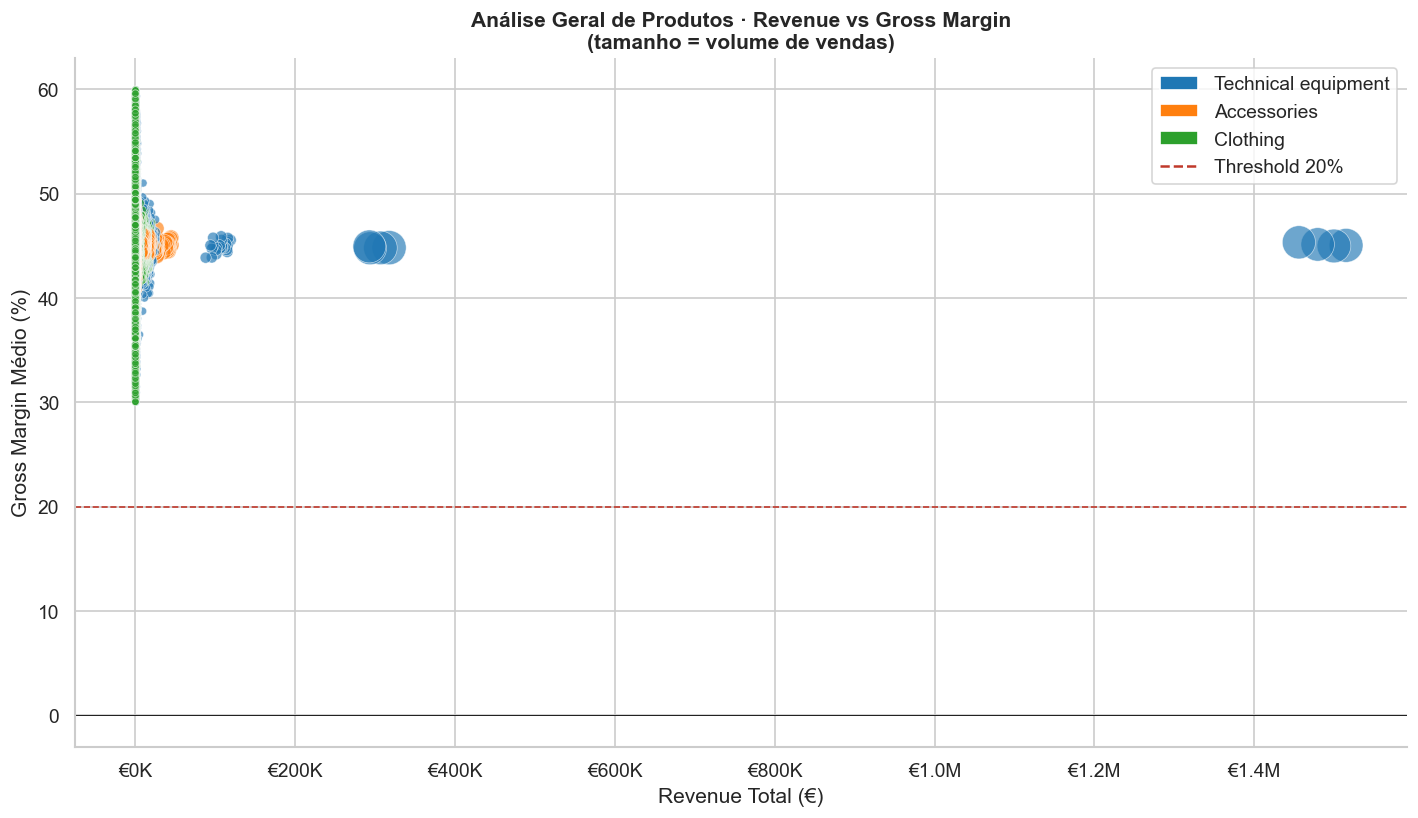

In [125]:
# ── Scatter: Revenue vs Margin % por Produto (bubble = volume) ────────────────
fig, ax = plt.subplots(figsize=(12, 7))

cat_color_map = {c: CAT_PAL[i] for i, c in enumerate(prod_summary['Main_Category'].unique())}
colors = [cat_color_map[c] for c in prod_summary['Main_Category']]

sc = ax.scatter(
    prod_summary['Revenue'],
    prod_summary['Margin_pct'],
    c=colors,
    s=prod_summary['Volume']/prod_summary['Volume'].max()*400+20,
    alpha=0.65,
    edgecolors='white',
    linewidth=0.4
)

ax.axhline(MARGIN_THRESHOLD, color=RED, linestyle='--', linewidth=1, label=f'Threshold Margin {MARGIN_THRESHOLD}%')
ax.axhline(0, color='black', linewidth=0.5)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(FMT_EUR))
ax.set_xlabel('Revenue Total (€)')
ax.set_ylabel('Gross Margin Médio (%)')
ax.set_title('Análise Geral de Produtos · Revenue vs Gross Margin\n(tamanho = volume de vendas)', fontweight='bold')

# Legenda de categorias
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=cat_color_map[c], label=c) for c in cat_color_map]
ax.legend(handles=legend_els + [plt.Line2D([0],[0], color=RED, linestyle='--', label=f'Threshold {MARGIN_THRESHOLD}%')],
          bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('scatter_produtos_revenue_margin.png', bbox_inches='tight')
plt.show()

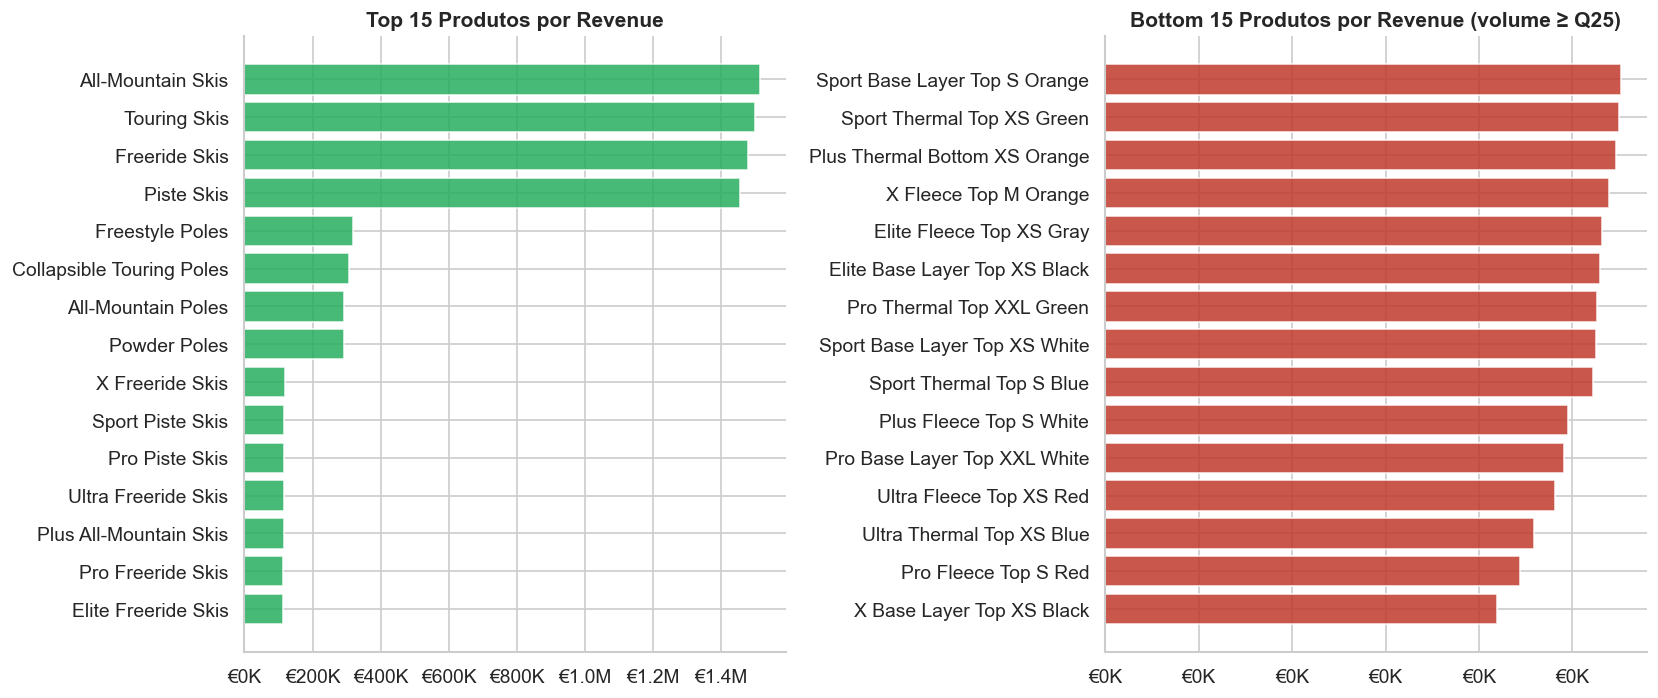

In [126]:
# ── Top 15 e Bottom 15 produtos por Revenue ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15
top15p = prod_summary.head(15)
axes[0].barh(top15p['Product_Name'].str[:30], top15p['Revenue'],
             color=GREEN, edgecolor='white', alpha=0.85)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(FMT_EUR))
axes[0].set_title('Top 15 Produtos por Revenue', fontweight='bold')
axes[0].invert_yaxis()

# Bottom 15 (com volume > threshold para excluir raridades)
vol_thr = prod_summary['Volume'].quantile(0.25)
bot15p  = prod_summary[prod_summary['Volume'] >= vol_thr].tail(15)
axes[1].barh(bot15p['Product_Name'].str[:30], bot15p['Revenue'],
             color=RED, edgecolor='white', alpha=0.85)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(FMT_EUR))
axes[1].set_title('Bottom 15 Produtos por Revenue (volume ≥ Q25)', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('top_bottom_produtos.png', bbox_inches='tight')
plt.show()

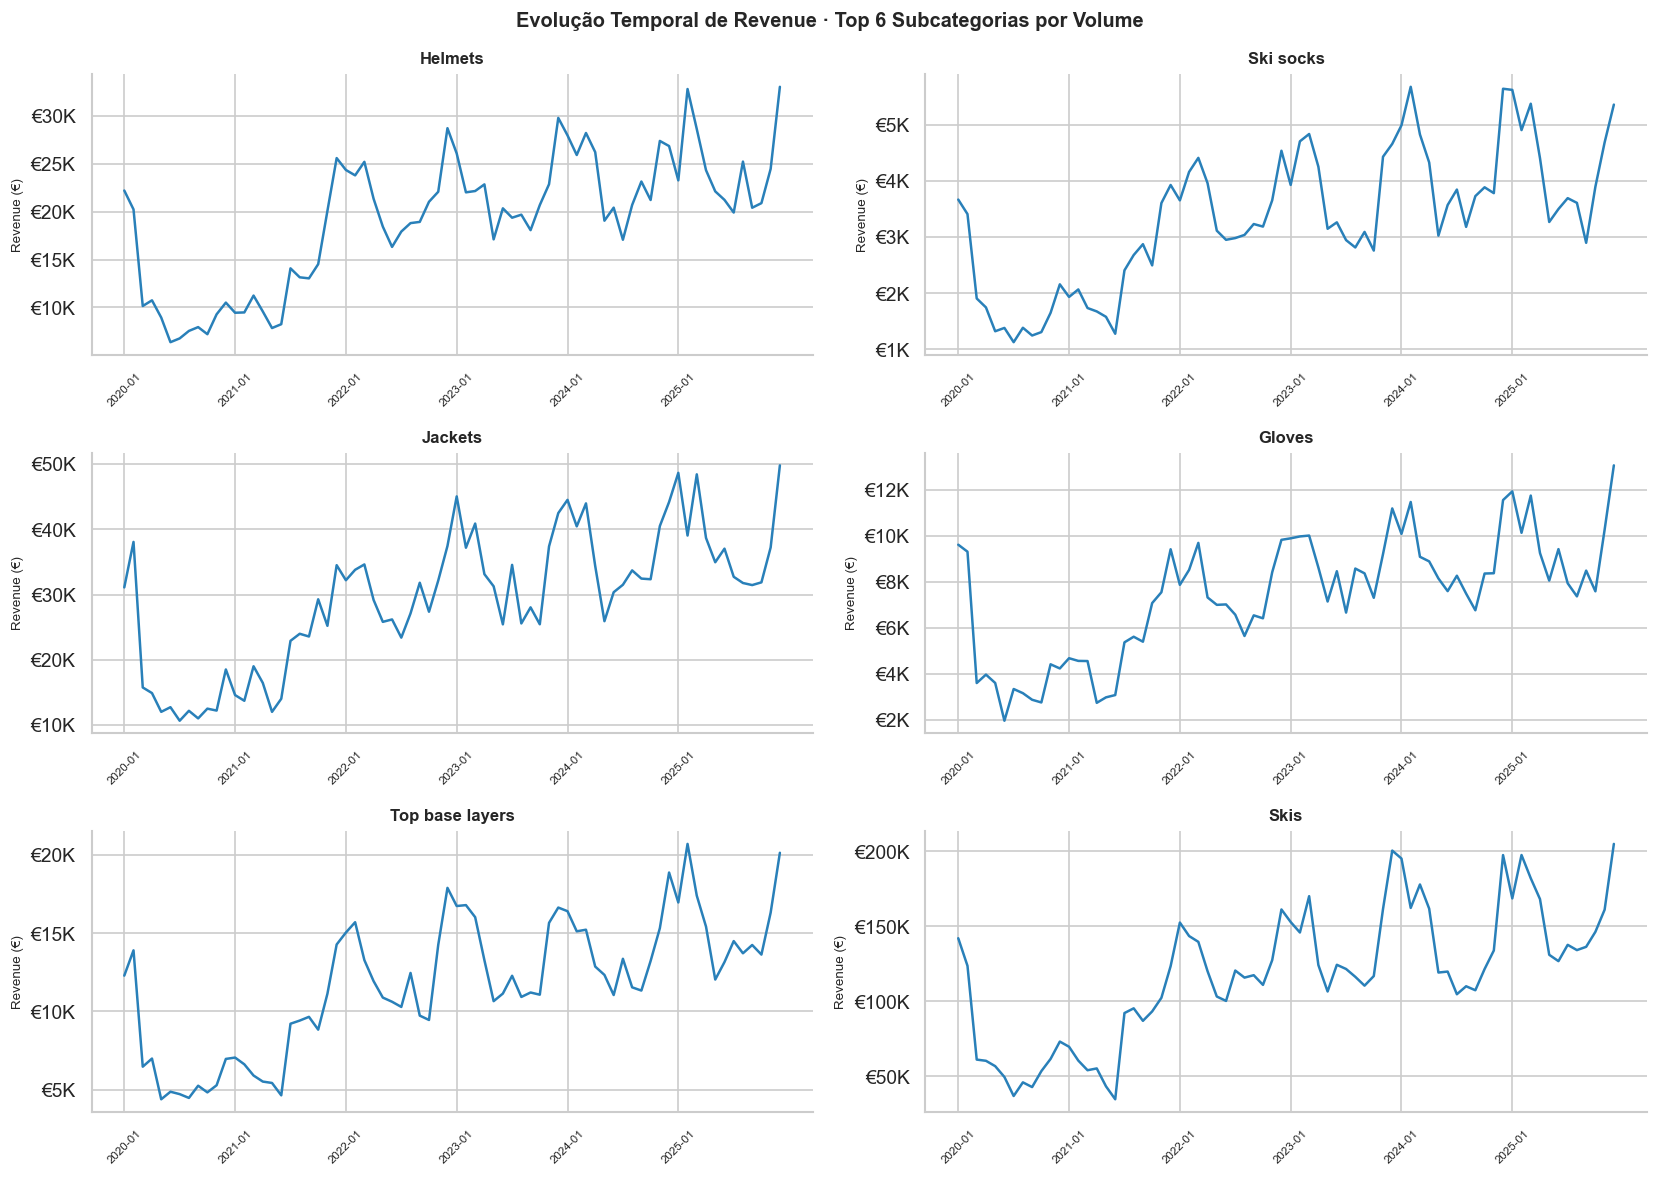

In [127]:
# ── Evolução temporal de vendas por Subcategoria ───────────────────────────────
if len(years) >= 2:
    ts_sub = (
        df.groupby(['Year', 'Month', 'Main_Category', 'Subcategory'])
        .agg(Revenue=('Sales_Price','sum'), Volume=('Sales_Order_ID','count'), GP=('GP','sum'))
        .reset_index()
    )
    ts_sub['Period'] = ts_sub['Year'].astype(str) + '-' + ts_sub['Month'].astype(str).str.zfill(2)

    top_subs_vol = df.groupby('Subcategory')['Sales_Order_ID'].count().nlargest(6).index.tolist()

    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, sub_name in zip(axes, top_subs_vol):
        s = ts_sub[ts_sub['Subcategory'] == sub_name].sort_values('Period')
        ax.plot(range(len(s)), s['Revenue'], color=BLUE, linewidth=1.5, label='Revenue')
        ax.set_xticks(range(0, len(s), max(1, len(s)//6)))
        ax.set_xticklabels(s['Period'].iloc[::max(1, len(s)//6)], rotation=45, fontsize=7)
        ax.set_title(sub_name, fontweight='bold', fontsize=10)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(FMT_EUR))
        ax.set_ylabel('Revenue (€)', fontsize=8)

    plt.suptitle('Evolução Temporal de Revenue · Top 6 Subcategorias por Volume', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('evolucao_temporal_subcategorias.png', bbox_inches='tight')
    plt.show()

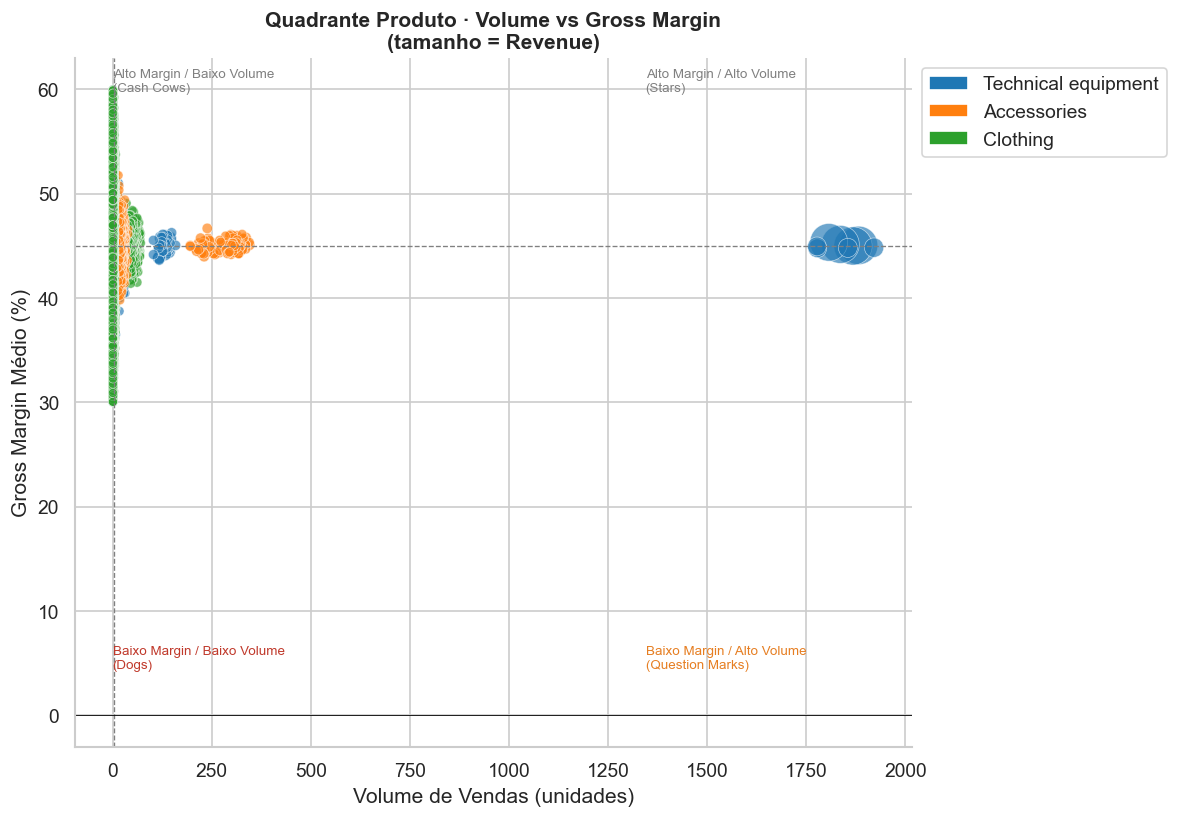

In [128]:
# ── Quadrante BCG simplificado: Volume vs Margin ──────────────────────────────
# Eixo X: Crescimento de Volume (se ≥ 2 anos)
# Eixo Y: Gross Margin %
# Tamanho: Revenue

fig, ax = plt.subplots(figsize=(10, 7))

x_med = prod_summary['Volume'].median()
y_med = prod_summary['Margin_pct'].median()

ax.scatter(
    prod_summary['Volume'],
    prod_summary['Margin_pct'],
    c=[cat_color_map[c] for c in prod_summary['Main_Category']],
    s=prod_summary['Revenue']/prod_summary['Revenue'].max()*500+30,
    alpha=0.65, edgecolors='white', linewidth=0.4
)

ax.axvline(x_med, color='grey', linestyle='--', linewidth=0.8)
ax.axhline(y_med, color='grey', linestyle='--', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.5)

# Rótulos dos quadrantes
ax.text(x_med*0.05, ax.get_ylim()[1]*0.95, 'Alto Margin / Baixo Volume\n(Cash Cows)', fontsize=8, color='grey', ha='left')
ax.text(prod_summary['Volume'].max()*0.7, ax.get_ylim()[1]*0.95, 'Alto Margin / Alto Volume\n(Stars)', fontsize=8, color='grey', ha='left')
ax.text(x_med*0.05, y_med*0.1, 'Baixo Margin / Baixo Volume\n(Dogs)', fontsize=8, color=RED, ha='left')
ax.text(prod_summary['Volume'].max()*0.7, y_med*0.1, 'Baixo Margin / Alto Volume\n(Question Marks)', fontsize=8, color=ORANGE, ha='left')

ax.set_xlabel('Volume de Vendas (unidades)')
ax.set_ylabel('Gross Margin Médio (%)')
ax.set_title('Quadrante Produto · Volume vs Gross Margin\n(tamanho = Revenue)', fontweight='bold')

legend_els = [Patch(facecolor=cat_color_map[c], label=c) for c in cat_color_map]
ax.legend(handles=legend_els, bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('quadrante_produtos.png', bbox_inches='tight')
plt.show()

---
## Sumário de Insights & Recomendações

In [129]:
print('=' * 70)
print('SUMÁRIO DE INSIGHTS — EIXO PRODUTO')
print('=' * 70)

# P-A2
n_risco = (pa2['Flag'] == 'Risco').sum()
print(f'\n[P-A2] Subcategorias com Gross Margin < {MARGIN_THRESHOLD}%: {n_risco}')
for _, r in pa2[pa2['Flag'] == 'Risco'].iterrows():
    print(f'  → {r["Main_Category"]} · {r["Subcategory"]:20s}  Margin: {r["Margin_pct"]:.1f}%  Revenue: €{r["Revenue"]:,.0f}')

# P-A3
n_custo = pa3['Alerta'].sum()
print(f'\n[P-A3] Subcategorias com Production Cost Ratio > {COST_THRESHOLD}%: {n_custo}')
for _, r in pa3[pa3['Alerta']].iterrows():
    print(f'  → {r["Main_Category"]} · {r["Subcategory"]:20s}  Cost Ratio: {r["Avg_Cost_Ratio"]:.1f}%')

# P-B1
print(f'\n[P-B1] Produto com maior dispersão de preço entre países:')
top_disp = pb1_spread.iloc[0]
print(f'  → {top_disp["Product_Name"]}  Range: {top_disp["Range_pct"]:.1f}%  (€{top_disp["Min_Price"]:.0f} – €{top_disp["Max_Price"]:.0f})')

# Pareto
print(f'\n[Pareto] {pareto_80} produtos concentram 80% da receita total.')

# Delivery
if len(df_del) > 0:
    top_del = del_cat.iloc[0]
    print(f'\n[Entrega] Subcategoria com maior tempo médio de entrega: {top_del["Subcategory"]} ({top_del["Avg_Days"]:.1f} dias)')

print('\n' + '=' * 70)

SUMÁRIO DE INSIGHTS — EIXO PRODUTO

[P-A2] Subcategorias com Gross Margin < 20%: 0

[P-A3] Subcategorias com Production Cost Ratio > 70%: 0

[P-B1] Produto com maior dispersão de preço entre países:
  → Elite Base Layer Bottom XS Orange  Range: 210.7%  (€33 – €270)

[Pareto] 1208 produtos concentram 80% da receita total.

[Entrega] Subcategoria com maior tempo médio de entrega: Boots (5.1 dias)

